# Naive Bayes from Scratch

Curso: Minería de Datos en la Practica (UNAM)

Autor: Thanos Drossos

This notebook implements a Naive Bayes classifier from scratch to identify potential mobile home insurance purchasers using the COIL dataset. The analysis progresses from uniperspective driver identification through multiperspective pair analysis to customer scoring, achieving a 4.18x lift for the top 100 customers. The methodology translates raw insurance data into actionable marketing insights by isolating the most influential customer characteristics and their interactions.

## Uniperspective Driver Analysis

Loads and preprocesses data, mapping data to enhance the descriptions, analyzes the features and calculated epislon values for each feature. Creates a dataframe with the most impactful drivers measured by epsilon.

In [69]:
import pandas as pd
import numpy as np
import math

# Load the dataset
df = pd.read_csv('tic_training.csv')

# Function to calculate Naive Bayes statistics for a feature-value pair
def calculate_stats(feature, value, description, subcategory, is_threshold=False):
    if is_threshold:
        condition = df[feature] >= value
        value_display = f"≥ {value}"
        response = value_display
    else:
        condition = df[feature] == value
        value_display = value
        response = str(value)
    
    # Count instances
    N_X = condition.sum()
    N_CX = ((df['CARAVAN'] == 1) & condition).sum()
    N_not_CX = N_X - N_CX
    
    # Calculate probabilities
    P_C_given_X = N_CX / N_X if N_X > 0 else 0
    prior_probability = df['CARAVAN'].mean()
    
    # Calculate Epsilon
    if N_X > 0 and prior_probability < 1 and prior_probability > 0:
        epsilon = (N_X * (P_C_given_X - prior_probability)) / (N_X * prior_probability * (1 - prior_probability))**0.5
    else:
        epsilon = 0
    
    # Calculate Score
    positive_instances = df['CARAVAN'].sum()
    negative_instances = len(df) - positive_instances
    P_X_given_C = N_CX / positive_instances if positive_instances > 0 else 0
    P_X_given_not_C = N_not_CX / negative_instances if negative_instances > 0 else 0
    
    if P_X_given_not_C > 0 and P_X_given_C > 0:
        score_X = math.log(P_X_given_C / P_X_given_not_C)
    else:
        score_X = 0
    
    s_r = math.log(prior_probability / (1 - prior_probability)) if prior_probability < 1 and prior_probability > 0 else 0
    score = score_X + s_r
    
    return {
        'Subcategoría': subcategory,
        'Descripción': description,
        'Respuesta': response,
        'N(CX)': N_CX,
        'N(X)': N_X,
        'P(C|X)': round(P_C_given_X, 2),
        'P(C)': round(prior_probability, 2),
        'Epsilon': round(epsilon, 2),
        'Score': round(score, 2),
        'N(C)': positive_instances,
        'N': len(df),
        'N(-C)': negative_instances,
        'N(-CX)': N_not_CX
    }

# Complete mapping of field codes to their descriptions
field_descriptions = {
    # Demographic data (1-43)
    'MOSTYPE': 'Customer Subtype',
    'MAANTHUI': 'Number of houses',
    'MGEMOMV': 'Average size household',
    'MGEMLEEF': 'Average age',
    'MOSHOOFD': 'Customer main type',
    'MGODRK': 'Roman catholic',
    'MGODPR': 'Protestant',
    'MGODOV': 'Other religion',
    'MGODGE': 'No religion',
    'MRELGE': 'Married',
    'MRELSA': 'Living together',
    'MRELOV': 'Other relation',
    'MFALLEEN': 'Singles',
    'MFGEKIND': 'Household without children',
    'MFWEKIND': 'Household with children',
    'MOPLHOOG': 'High level education',
    'MOPLMIDD': 'Medium level education',
    'MOPLLAAG': 'Lower level education',
    'MBERHOOG': 'High status',
    'MBERZELF': 'Entrepreneur',
    'MBERBOER': 'Farmer',
    'MBERMIDD': 'Middle management',
    'MBERARBG': 'Skilled laborers',
    'MBERARBO': 'Unskilled laborers',
    'MSKA': 'Social class A',
    'MSKB1': 'Social class B1',
    'MSKB2': 'Social class B2',
    'MSKC': 'Social class C',
    'MSKD': 'Social class D',
    'MHHUUR': 'Rented house',
    'MHKOOP': 'Home owners',
    'MAUT1': '1 car',
    'MAUT2': '2 cars',
    'MAUT0': 'No car',
    'MZFONDS': 'National Health Service',
    'MZPART': 'Private health insurance',
    'MINKM30': 'Income < 30.000',
    'MINK3045': 'Income 30-45.000',
    'MINK4575': 'Income 45-75.000',
    'MINK7512': 'Income 75-122.000',
    'MINK123M': 'Income >123.000',
    'MINKGEM': 'Average income',
    'MKOOPKLA': 'Purchasing power class',
    
    # Contribution (insurance premium payment) fields (44-64)
    'PWAPART': 'Contribution private third party insurance',
    'PWABEDR': 'Contribution third party insurance (firms)',
    'PWALAND': 'Contribution third party insurance (agriculture)',
    'PPERSAUT': 'Contribution car policies',
    'PBESAUT': 'Contribution delivery van policies',
    'PMOTSCO': 'Contribution motorcycle/scooter policies',
    'PVRAAUT': 'Contribution lorry policies',
    'PAANHANG': 'Contribution trailer policies',
    'PTRACTOR': 'Contribution tractor policies',
    'PWERKT': 'Contribution agricultural machines policies',
    'PBROM': 'Contribution moped policies',
    'PLEVEN': 'Contribution life insurances',
    'PPERSONG': 'Contribution private accident insurance policies',
    'PGEZONG': 'Contribution family accidents insurance policies',
    'PWAOREG': 'Contribution disability insurance policies',
    'PBRAND': 'Contribution fire policies',
    'PZEILPL': 'Contribution surfboard policies',
    'PPLEZIER': 'Contribution boat policies',
    'PFIETS': 'Contribution bicycle policies',
    'PINBOED': 'Contribution property insurance policies',
    'PBYSTAND': 'Contribution social security insurance policies',
    
    # Policy count fields (65-85)
    'AWAPART': 'Number of private third party insurance',
    'AWABEDR': 'Number of third party insurance (firms)',
    'AWALAND': 'Number of third party insurance (agriculture)',
    'APERSAUT': 'Number of car policies',
    'ABESAUT': 'Number of delivery van policies',
    'AMOTSCO': 'Number of motorcycle/scooter policies',
    'AVRAAUT': 'Number of lorry policies',
    'AAANHANG': 'Number of trailer policies',
    'ATRACTOR': 'Number of tractor policies',
    'AWERKT': 'Number of agricultural machines policies',
    'ABROM': 'Number of moped policies',
    'ALEVEN': 'Number of life insurances',
    'APERSONG': 'Number of private accident insurance policies',
    'AGEZONG': 'Number of family accidents insurance policies',
    'AWAOREG': 'Number of disability insurance policies',
    'ABRAND': 'Number of fire policies',
    'AZEILPL': 'Number of surfboard policies',
    'APLEZIER': 'Number of boat policies',
    'AFIETS': 'Number of bicycle policies',
    'AINBOED': 'Number of property insurance policies',
    'ABYSTAND': 'Number of social security insurance policies',
    
    # Target variable
    'CARAVAN': 'Number of mobile home policies'
}

# Customer subtypes (MOSTYPE) from L0
customer_subtypes = {
    1: 'High Income, expensive child',
    2: 'Very Important Provincials',
    3: 'High status seniors',
    4: 'Affluent senior apartments',
    5: 'Mixed seniors',
    6: 'Career and childcare',
    7: "Dinki's (double income no kids)",
    8: 'Middle class families',
    9: 'Modern, complete families',
    10: 'Stable family',
    11: 'Family starters',
    12: 'Affluent young families',
    13: 'Young all american family',
    14: 'Junior cosmopolitan',
    15: 'Senior cosmopolitans',
    16: 'Students in apartments',
    17: 'Fresh masters in the city',
    18: 'Single youth',
    19: 'Suburban youth',
    20: 'Ethnically diverse',
    21: 'Young urban have-nots',
    22: 'Mixed apartment dwellers',
    23: 'Young and rising',
    24: 'Young, low educated',
    25: 'Young seniors in the city',
    26: 'Own home elderly',
    27: 'Seniors in apartments',
    28: 'Residential elderly',
    29: 'Porchless seniors: no front yard',
    30: 'Religious elderly singles',
    31: 'Low income catholics',
    32: 'Mixed seniors',
    33: 'Lower class large families',
    34: 'Large family, employed child',
    35: 'Village families',
    36: "Couples with teens 'Married with children'",
    37: 'Mixed small town dwellers',
    38: 'Traditional families',
    39: 'Large religious families',
    40: 'Large family farms',
    41: 'Mixed rurals'
}

# Age descriptions for MGEMLEEF (L1)
age_descriptions = {
    1: '20-30 years',
    2: '30-40 years',
    3: '40-50 years',
    4: '50-60 years',
    5: '60-70 years',
    6: '70-80 years'
}

# Customer main type descriptions for MOSHOOFD (L2)
customer_main_descriptions = {
    1: 'Successful hedonists',
    2: 'Driven Growers',
    3: 'Average Family',
    4: 'Career Loners',
    5: 'Living well',
    6: 'Cruising Seniors',
    7: 'Retired and Religious',
    8: 'Family with grown ups',
    9: 'Conservative families',
    10: 'Farmers'
}

# Percentage descriptions (L3)
percentage_descriptions = {
    0: '0%',
    1: '1-10%',
    2: '11-23%',
    3: '24-36%',
    4: '37-49%',
    5: '50-62%',
    6: '63-75%',
    7: '76-88%',
    8: '89-99%',
    9: '100%'
}

# Contribution amounts (L4)
contribution_descriptions = {
    0: '0',
    1: '1-49',
    2: '50-99',
    3: '100-199',
    4: '200-499',
    5: '500-999',
    6: '1000-4999',
    7: '5000-9999',
    8: '10,000-19,999',
    9: '20,000+'
}

# Function to enhance driver descriptions with meaningful labels
def enhance_description(description):
    parts = description.split(' = ')
    if len(parts) == 2:
        field, value = parts
        try:
            value = int(value)
            
            if field in field_descriptions:
                field_desc = field_descriptions[field]
                
                # Apply specific value descriptions based on field type
                if field == 'MOSTYPE' and value in customer_subtypes:
                    value_desc = customer_subtypes[value]
                elif field == 'MGEMLEEF' and value in age_descriptions:
                    value_desc = age_descriptions[value]
                elif field == 'MOSHOOFD' and value in customer_main_descriptions:
                    value_desc = customer_main_descriptions[value]
                # Percentage fields (many sociodemographic variables)
                elif field.startswith('M') and value in percentage_descriptions:
                    value_desc = percentage_descriptions[value]
                # Contribution fields
                elif field.startswith('P') and value in contribution_descriptions:
                    value_desc = contribution_descriptions[value]
                # Count fields (policy counts)
                elif field.startswith('A'):
                    value_desc = str(value) + " policies"
                else:
                    value_desc = str(value)
                
                return f"{field_desc}: {value_desc}"
        except ValueError:
            pass
    
    # For thresholds (e.g., MINKGEM >= 4)
    if '>=' in description:
        parts = description.split(' >= ')
        if len(parts) == 2:
            field, threshold = parts
            try:
                threshold = int(threshold)
                
                if field in field_descriptions:
                    field_desc = field_descriptions[field]
                    
                    # Special case for income thresholds
                    if field == 'MINKGEM':
                        return f"{field_desc} >= level {threshold}"
                    elif field == 'MKOOPKLA':
                        return f"{field_desc} >= class {threshold}"
                    else:
                        return f"{field_desc} >= {threshold}"
            except ValueError:
                pass
    
    # Default: return the original description
    return description

# List of features to analyze
features_to_analyze = [
    # Demographics
    'MOSTYPE', 'MOSHOOFD', 'MGEMLEEF', 'MAANTHUI', 'MGEMOMV',
    # Religion/relationships
    'MGODRK', 'MGODPR', 'MGODOV', 'MGODGE', 'MRELGE', 'MRELSA', 'MRELOV',
    # Family status
    'MFALLEEN', 'MFGEKIND', 'MFWEKIND',
    # Education
    'MOPLHOOG', 'MOPLMIDD', 'MOPLLAAG',
    # Professional status
    'MBERHOOG', 'MBERZELF', 'MBERBOER', 'MBERMIDD', 'MBERARBG', 'MBERARBO',
    # Social class
    'MSKA', 'MSKB1', 'MSKB2', 'MSKC', 'MSKD',
    # Housing
    'MHHUUR', 'MHKOOP',
    # Transportation
    'MAUT1', 'MAUT2', 'MAUT0',
    # Insurance
    'MZFONDS', 'MZPART',
    # Income
    'MINKM30', 'MINK3045', 'MINK4575', 'MINK7512', 'MINK123M', 'MINKGEM', 'MKOOPKLA',
    # Insurance contributions
    'PWAPART', 'PWABEDR', 'PWALAND', 'PPERSAUT', 'PBESAUT', 'PMOTSCO',
    'PVRAAUT', 'PAANHANG', 'PTRACTOR', 'PWERKT', 'PBROM', 'PLEVEN',
    'PPERSONG', 'PGEZONG', 'PWAOREG', 'PBRAND', 'PZEILPL', 'PPLEZIER',
    'PFIETS', 'PINBOED', 'PBYSTAND',
    # Number of policies
    'AWAPART', 'AWABEDR', 'AWALAND', 'APERSAUT', 'ABESAUT', 'AMOTSCO',
    'AVRAAUT', 'AAANHANG', 'ATRACTOR', 'AWERKT', 'ABROM', 'ALEVEN',
    'APERSONG', 'AGEZONG', 'AWAOREG', 'ABRAND', 'AZEILPL', 'APLEZIER',
    'AFIETS', 'AINBOED', 'ABYSTAND'
]

# Initialize results list
results = []

# Process each feature
for feature in features_to_analyze:
    # Determine category based on feature type
    if feature.startswith('M'):
        if feature in ['MOSTYPE', 'MOSHOOFD', 'MGEMLEEF', 'MAANTHUI', 'MGEMOMV']:
            category = 'Demographics'
        elif feature in ['MGODRK', 'MGODPR', 'MGODOV', 'MGODGE']:
            category = 'Religion'
        elif feature in ['MRELGE', 'MRELSA', 'MRELOV', 'MFALLEEN', 'MFGEKIND', 'MFWEKIND']:
            category = 'Family Status'
        elif feature in ['MOPLHOOG', 'MOPLMIDD', 'MOPLLAAG']:
            category = 'Education'
        elif feature in ['MBERHOOG', 'MBERZELF', 'MBERBOER', 'MBERMIDD', 'MBERARBG', 'MBERARBO']:
            category = 'Professional Status'
        elif feature in ['MSKA', 'MSKB1', 'MSKB2', 'MSKC', 'MSKD']:
            category = 'Social Class'
        elif feature in ['MHHUUR', 'MHKOOP']:
            category = 'Housing'
        elif feature in ['MAUT1', 'MAUT2', 'MAUT0']:
            category = 'Transportation'
        elif feature in ['MZFONDS', 'MZPART']:
            category = 'Health Insurance'
        elif feature in ['MINKM30', 'MINK3045', 'MINK4575', 'MINK7512', 'MINK123M', 'MINKGEM', 'MKOOPKLA']:
            category = 'Income'
        else:
            category = 'Sociodemographic'
    elif feature.startswith('P'):
        category = 'Insurance Contributions'
    elif feature.startswith('A'):
        category = 'Policy Counts'
    else:
        category = 'Other'
    
    # Analyze each unique value for the feature
    unique_values = sorted(df[feature].unique())
    for value in unique_values:
        description = f"{feature} = {value}"
        results.append(calculate_stats(feature, value, description, category))
    
    # For income and purchasing power features, also analyze threshold values
    if feature in ['MINKGEM', 'MKOOPKLA']:
        for threshold in range(1, 10):
            description = f"{feature} >= {threshold}"
            results.append(calculate_stats(feature, threshold, description, 'Income', is_threshold=True))

# Create DataFrame with results
results_df = pd.DataFrame(results)

# Sort by absolute epsilon value to find most significant factors
results_df = results_df.sort_values(by='Epsilon', ascending=False)

# Create the final output with enhanced descriptions and corrected percentage calculation
top_drivers = results_df.head(20)
output_df = pd.DataFrame({
    'Driver': top_drivers['Descripción'].apply(enhance_description),
    'Category': top_drivers['Subcategoría'],
    'Epsilon': top_drivers['Epsilon'],
    'Customers with Driver': top_drivers['N(X)'],
    'Purchasers with Driver': top_drivers['N(CX)'],
    # Calculate percentage directly from raw counts to avoid double rounding
    'Percentage (%)': ((top_drivers['N(CX)'] / top_drivers['N(X)']) * 100).round(2)
})

# Display the results
print("\nTop Uniperspective Drivers for Mobile Home Insurance:")
print(output_df)


Top Uniperspective Drivers for Mobile Home Insurance:
                                                Driver  \
469               Contribution car policies: 1000-4999   
537                Contribution fire policies: 200-499   
634                Number of boat policies: 1 policies   
440                     Purchasing power class: 76-88%   
7              Customer Subtype: Middle class families   
448                  Purchasing power class >= class 7   
41                  Customer main type: Driven Growers   
576                 Number of car policies: 2 policies   
575                 Number of car policies: 1 policies   
447                  Purchasing power class >= class 6   
453  Contribution private third party insurance: 50-99   
567  Number of private third party insurance: 1 pol...   
644  Number of social security insurance policies: ...   
428                          Average income >= level 4   
546                   Contribution boat policies: 1-49   
318              

## Multisperspective approach with 2 drivers

Uses a beam search approach to find the top pairs of individual drives. Iterates through all pais of the top 40 predictors to find the most promising ones.

In [70]:
# Function to calculate statistics for a pair of drivers
def calculate_pair_stats(feature1, value1, feature2, value2, is_threshold1=False, is_threshold2=False):
    # Create conditions for both features
    if is_threshold1:
        condition1 = df[feature1] >= value1
    else:
        condition1 = df[feature1] == value1
        
    if is_threshold2:
        condition2 = df[feature2] >= value2
    else:
        condition2 = df[feature2] == value2
    
    # Combined condition (logical AND)
    combined_condition = condition1 & condition2
    
    # Count instances
    N_X = combined_condition.sum()
    N_CX = ((df['CARAVAN'] == 1) & combined_condition).sum()
    N_not_CX = N_X - N_CX
    
    # Calculate probabilities
    P_C_given_X = N_CX / N_X if N_X > 0 else 0
    prior_probability = df['CARAVAN'].mean()
    
    # Calculate Epsilon
    if N_X > 0 and prior_probability < 1 and prior_probability > 0:
        epsilon = (N_X * (P_C_given_X - prior_probability)) / (N_X * prior_probability * (1 - prior_probability))**0.5
    else:
        epsilon = 0
    
    # Get descriptions
    description1 = f"{feature1} = {value1}" if not is_threshold1 else f"{feature1} >= {value1}"
    description2 = f"{feature2} = {value2}" if not is_threshold2 else f"{feature2} >= {value2}"
    combined_description = f"{description1} AND {description2}"
    
    # Determine category
    categories = []
    for feature in [feature1, feature2]:
        if feature.startswith('M'):
            if feature in ['MOSTYPE', 'MOSHOOFD', 'MGEMLEEF', 'MAANTHUI', 'MGEMOMV']:
                categories.append('Demographics')
            elif feature in ['MGODRK', 'MGODPR', 'MGODOV', 'MGODGE']:
                categories.append('Religion')
            elif feature in ['MRELGE', 'MRELSA', 'MRELOV', 'MFALLEEN', 'MFGEKIND', 'MFWEKIND']:
                categories.append('Family Status')
            elif feature in ['MOPLHOOG', 'MOPLMIDD', 'MOPLLAAG']:
                categories.append('Education')
            elif feature in ['MBERHOOG', 'MBERZELF', 'MBERBOER', 'MBERMIDD', 'MBERARBG', 'MBERARBO']:
                categories.append('Professional Status')
            else:
                categories.append('Sociodemographic')
        elif feature.startswith('P'):
            categories.append('Insurance Contributions')
        elif feature.startswith('A'):
            categories.append('Policy Counts')
        else:
            categories.append('Other')
    
    category = ' + '.join(sorted(set(categories)))
    
    return {
        'Description': combined_description,
        'Category': category,
        'N(X)': N_X,
        'N(CX)': N_CX,
        'Epsilon': round(epsilon, 2),
        'Driver1': description1,
        'Driver2': description2,
        'Is_Threshold1': is_threshold1,
        'Is_Threshold2': is_threshold2,
        'Feature1': feature1,
        'Value1': value1,
        'Feature2': feature2,
        'Value2': value2
    }

# Get top uniperspective drivers for beam search
top_n = 40  # Adjust based on computational capacity, focus only on top 40 drivers
top_uniperspective = results_df.sort_values(by='Epsilon', ascending=False).head(top_n)

# Initialize list for multiperspective results
multiperspective_results = []

# Generate and evaluate pairs (using beam search approach)
print("Searching for multiperspective drivers...")

# Extract feature-value pairs from top uniperspective drivers
driver_pairs = []
for i, row1 in top_uniperspective.iterrows():
    desc1 = row1['Descripción']
    
    # Check if it's a threshold condition
    is_threshold1 = '>=' in desc1
    if is_threshold1:
        parts = desc1.split(' >= ')
        feature1 = parts[0]
        value1 = int(parts[1])
    else:
        parts = desc1.split(' = ')
        feature1 = parts[0]
        value1 = int(parts[1])
    
    for j, row2 in top_uniperspective.iterrows():
        if i >= j:  # Avoid duplicates and same-feature pairs
            continue
            
        desc2 = row2['Descripción']
        
        # Check if it's a threshold condition
        is_threshold2 = '>=' in desc2
        if is_threshold2:
            parts = desc2.split(' >= ')
            feature2 = parts[0]
            value2 = int(parts[1])
        else:
            parts = desc2.split(' = ')
            feature2 = parts[0]
            value2 = int(parts[1])
        
        # Avoid pairs of the same feature
        if feature1 == feature2:
            continue
        
        # Calculate stats for this pair
        pair_stats = calculate_pair_stats(
            feature1, value1, feature2, value2, 
            is_threshold1=is_threshold1, 
            is_threshold2=is_threshold2
        )
        
        # Only consider pairs with sufficient support (at least 30 customers)
        if pair_stats['N(X)'] >= 30:
            multiperspective_results.append(pair_stats)

# Convert to DataFrame and sort by epsilon
multiperspective_df = pd.DataFrame(multiperspective_results)
multiperspective_df = multiperspective_df.sort_values(by='Epsilon', ascending=False)

# Enhance descriptions for the top pairs
def enhance_pair_description(row):
    # Enhance description for first driver
    if row['Is_Threshold1']:
        parts = row['Driver1'].split(' >= ')
        feature = parts[0]
        value = int(parts[1])
        enhanced1 = enhance_description(f"{feature} >= {value}")
    else:
        parts = row['Driver1'].split(' = ')
        feature = parts[0]
        value = int(parts[1])
        enhanced1 = enhance_description(f"{feature} = {value}")
    
    # Enhance description for second driver
    if row['Is_Threshold2']:
        parts = row['Driver2'].split(' >= ')
        feature = parts[0]
        value = int(parts[1])
        enhanced2 = enhance_description(f"{feature} >= {value}")
    else:
        parts = row['Driver2'].split(' = ')
        feature = parts[0]
        value = int(parts[1])
        enhanced2 = enhance_description(f"{feature} = {value}")
    
    return f"{enhanced1} AND {enhanced2}"

# Create final output DataFrame with enhanced descriptions
top_pairs = multiperspective_df.head(20)
output_pairs_df = pd.DataFrame({
    'Driver Combination': top_pairs.apply(enhance_pair_description, axis=1),
    'Category': top_pairs['Category'],
    'Epsilon': top_pairs['Epsilon'],
    'Customers with Both Drivers': top_pairs['N(X)'],
    'Purchasers with Both Drivers': top_pairs['N(CX)'],
    'Percentage (%)': ((top_pairs['N(CX)'] / top_pairs['N(X)']) * 100).round(2)
})

# Display the results
print("\nTop Multiperspective Drivers for Mobile Home Insurance:")
print(output_pairs_df)

Searching for multiperspective drivers...

Top Multiperspective Drivers for Mobile Home Insurance:
                                    Driver Combination  \
77   Purchasing power class >= class 6 AND Contribu...   
0    Contribution car policies: 1000-4999 AND Contr...   
96   Average income >= level 4 AND Contribution car...   
144  Purchasing power class >= class 5 AND Contribu...   
5    Contribution car policies: 1000-4999 AND Numbe...   
41   Purchasing power class >= class 7 AND Contribu...   
85   Contribution private third party insurance: 50...   
3    Contribution car policies: 1000-4999 AND Numbe...   
384  Purchasing power class >= class 4 AND Contribu...   
97   Average income >= level 4 AND Contribution fir...   
48   Customer main type: Driven Growers AND Contrib...   
78   Purchasing power class >= class 6 AND Contribu...   
385  Purchasing power class >= class 4 AND Contribu...   
145  Purchasing power class >= class 5 AND Contribu...   
126  Rented house: 0% AND Contr

## Using the score to identify predictors

Implements a predictive model using naive bayes to score each customer on their likelihood to purchase mobile home insurance.

Feature selection: search top 10 multipersepctive pairs (based on epsilon) and include non-redundant feature pairs in scoring model. Then, take top 20 uniperspective drivers and include features that were not already used in pairs.

Shows that in this case, only 14 features were selected for the model.

In [71]:
import numpy as np
import pandas as pd
import math
from tqdm import tqdm

def calculate_customer_scores(df, top_drivers, top_pairs):
    print("Calculating scores for all customers...")
    
    # Get prior probability of having a caravan policy
    prior_probability = df['CARAVAN'].mean()
    prior_odds = prior_probability / (1 - prior_probability)
    log_prior = math.log(prior_odds) if prior_odds > 0 else 0
    
    # Initialize array for scores
    customer_scores = np.ones(len(df)) * log_prior
    
    # Dictionary to store likelihood ratios for feature-value pairs
    likelihood_ratios = {}

    # Track features used to avoid duplicate counting
    used_features = set()
    selected_pairs = []
    selected_single_features = []
    
    # Track features used to avoid duplicate counting
    used_features = set()
    
    # First use the top multiperspective pairs (stronger signal)
    for _, pair in top_pairs.iterrows():
        feature1 = pair['Feature1']
        value1 = pair['Value1']
        is_threshold1 = pair['Is_Threshold1']
        
        feature2 = pair['Feature2']
        value2 = pair['Value2']
        is_threshold2 = pair['Is_Threshold2']
        
        # Skip if either feature already used
        if feature1 in used_features or feature2 in used_features:
            continue
            
        # Add both features to the used set
        used_features.add(feature1)
        used_features.add(feature2)

        # Record the selected pair
        pair_desc = {
            'feature1': feature1, 
            'value1': value1, 
            'is_threshold1': is_threshold1,
            'feature2': feature2, 
            'value2': value2, 
            'is_threshold2': is_threshold2
        }
        selected_pairs.append(pair_desc)
        
        # Calculate likelihood ratios for this pair
        if is_threshold1:
            condition1 = df[feature1] >= value1
        else:
            condition1 = df[feature1] == value1
            
        if is_threshold2:
            condition2 = df[feature2] >= value2
        else:
            condition2 = df[feature2] == value2
            
        condition = condition1 & condition2
        
        # Count customers with and without caravan policies
        positive_instances = df['CARAVAN'].sum()
        negative_instances = len(df) - positive_instances
        
        # Calculate conditional probabilities with Laplace smoothing
        count_with_C = ((df['CARAVAN'] == 1) & condition).sum() + 1
        count_with_not_C = (condition & (df['CARAVAN'] == 0)).sum() + 1
        
        P_X_given_C = count_with_C / (positive_instances + 2)
        P_X_given_not_C = count_with_not_C / (negative_instances + 2)
        
        # Calculate log likelihood ratio for this pair
        log_ratio = math.log(P_X_given_C / P_X_given_not_C)
        
        # Apply to matching customers
        customer_scores[condition] += log_ratio
        
        # For customers that don't match this pair, apply the complement likelihood
        comp_count_with_C = positive_instances - ((df['CARAVAN'] == 1) & condition).sum() + 1
        comp_count_with_not_C = negative_instances - (condition & (df['CARAVAN'] == 0)).sum() + 1
        comp_P_X_given_C = comp_count_with_C / (positive_instances + 2)
        comp_P_X_given_not_C = comp_count_with_not_C / (negative_instances + 2)
        comp_log_ratio = math.log(comp_P_X_given_C / comp_P_X_given_not_C)
        
        customer_scores[~condition] += comp_log_ratio
    
    # Then add top uniperspective drivers for features not yet used
    for _, row in top_drivers.iterrows():
        desc = row['Descripción']
        is_threshold = '>=' in desc
        
        if is_threshold:
            parts = desc.split(' >= ')
            feature = parts[0]
            value = int(parts[1])
        else:
            parts = desc.split(' = ')
            feature = parts[0]
            value = int(parts[1])
        
        # Skip if feature already used in pairs
        if feature in used_features:
            continue
            
        # Add feature to used set
        used_features.add(feature)

        # Record the selected single feature
        feature_desc = {
            'feature': feature,
            'value': value,
            'is_threshold': is_threshold
        }
        selected_single_features.append(feature_desc)
        
        # Create condition
        if is_threshold:
            condition = df[feature] >= value
        else:
            condition = df[feature] == value
        
        # Count customers with and without caravan policies
        positive_instances = df['CARAVAN'].sum()
        negative_instances = len(df) - positive_instances
        
        # Calculate conditional probabilities with Laplace smoothing
        count_with_C = ((df['CARAVAN'] == 1) & condition).sum() + 1
        count_with_not_C = (condition & (df['CARAVAN'] == 0)).sum() + 1
        
        P_X_given_C = count_with_C / (positive_instances + 2)
        P_X_given_not_C = count_with_not_C / (negative_instances + 2)
        
        # Calculate log likelihood ratio
        log_ratio = math.log(P_X_given_C / P_X_given_not_C)
        
        # Apply to matching customers
        customer_scores[condition] += log_ratio
        
        # For customers that don't match, apply the complement likelihood
        comp_count_with_C = positive_instances - ((df['CARAVAN'] == 1) & condition).sum() + 1
        comp_count_with_not_C = negative_instances - (condition & (df['CARAVAN'] == 0)).sum() + 1
        comp_P_X_given_C = comp_count_with_C / (positive_instances + 2)
        comp_P_X_given_not_C = comp_count_with_not_C / (negative_instances + 2)
        comp_log_ratio = math.log(comp_P_X_given_C / comp_P_X_given_not_C)
        
        customer_scores[~condition] += comp_log_ratio
        
    # Create DataFrame with customer IDs and scores
    scores_df = pd.DataFrame({
        'CustomerID': df['NID'],
        'Score': customer_scores,
        'Probability': 1 / (1 + np.exp(-customer_scores)),  # Convert log-odds to probability
        'Actual': df['CARAVAN']
    })
    
    # Sort by score in descending order
    scores_df = scores_df.sort_values(by='Score', ascending=False)
    
    # Calculate lift for the top N groups
    for n in [100, 200, 300, 500, 1000]:
        if len(scores_df) >= n:
            top_n = scores_df.head(n)
            lift = (top_n['Actual'].mean() / prior_probability)
            print(f"Lift for top {n} customers: {lift:.2f}x")
    
    return scores_df, used_features, selected_pairs, selected_single_features


# Calculate scores using both uniperspective and multiperspective drivers
top_uniperspective_for_scoring = results_df.sort_values(by='Epsilon', ascending=False).head(20)
top_multiperspective_for_scoring = multiperspective_df.head(10)

# Calculate scores and get selected features
customer_scores, used_features, selected_pairs, selected_single_features = calculate_customer_scores(
    df, top_uniperspective_for_scoring, top_multiperspective_for_scoring
)

# Display selected features
print("\n=== FEATURES SELECTED FOR THE FINAL MODEL ===")

print("\nSelected Feature Pairs:")
for i, pair in enumerate(selected_pairs, 1):
    # Format the first feature
    if pair['is_threshold1']:
        feature1_desc = f"{pair['feature1']} >= {pair['value1']}"
    else:
        feature1_desc = f"{pair['feature1']} = {pair['value1']}"
    
    # Format the second feature
    if pair['is_threshold2']:
        feature2_desc = f"{pair['feature2']} >= {pair['value2']}"
    else:
        feature2_desc = f"{pair['feature2']} = {pair['value2']}"
    
    # Get readable descriptions if possible
    try:
        feature1_readable = enhance_description(feature1_desc)
        feature2_readable = enhance_description(feature2_desc)
        print(f"{i}. {feature1_readable} AND {feature2_readable}")
    except:
        print(f"{i}. {feature1_desc} AND {feature2_desc}")

print("\nSelected Individual Features:")
for i, feature in enumerate(selected_single_features, 1):
    if feature['is_threshold']:
        feature_desc = f"{feature['feature']} >= {feature['value']}"
    else:
        feature_desc = f"{feature['feature']} = {feature['value']}"
    
    # Get readable description if possible
    try:
        feature_readable = enhance_description(feature_desc)
        print(f"{i}. {feature_readable}")
    except:
        print(f"{i}. {feature_desc}")

print(f"\nTotal number of unique features used: {len(used_features)}")
print("Feature list:", ", ".join(sorted(used_features)))

# Display the top 20 customers most likely to purchase
print("\nTop 20 Customers Most Likely to Purchase Mobile Home Insurance:")
top_customers = customer_scores.head(20)
print(top_customers[['CustomerID', 'Score', 'Probability', 'Actual']])

# Calculate performance metrics
total_positive = df['CARAVAN'].sum()
print(f"\nTotal customers with caravan policies: {total_positive}")
print(f"Baseline probability: {(total_positive / len(df)) * 100:.2f}%")

# Calculate precision at different thresholds
for k in [100, 200, 500, 1000]:
    if len(customer_scores) >= k:
        precision = customer_scores.head(k)['Actual'].sum() / k
        recall = customer_scores.head(k)['Actual'].sum() / total_positive
        print(f"Precision@{k}: {precision*100:.2f}%, Recall@{k}: {recall*100:.2f}%")


train_precision = {}
train_recall = {}
train_lift = {}

# Store precision and recall values
for k in [100, 200, 500, 1000]:
    if len(customer_scores) >= k:
        precision = customer_scores.head(k)['Actual'].sum() / k
        recall = customer_scores.head(k)['Actual'].sum() / total_positive
        train_precision[k] = precision * 100  # Store as percentage
        train_recall[k] = recall * 100  # Store as percentage

# Store lift values
for n in [100, 200, 300, 500, 1000]:
    if len(customer_scores) >= n:
        lift = (customer_scores.head(n)['Actual'].mean() / (total_positive / len(df)))
        train_lift[n] = lift

# Store baseline probability
train_baseline = (total_positive / len(df)) * 100

print("\nTraining metrics saved for future use in visualizations and analysis.")

Calculating scores for all customers...
Lift for top 100 customers: 4.18x
Lift for top 200 customers: 4.77x
Lift for top 300 customers: 4.24x
Lift for top 500 customers: 3.81x
Lift for top 1000 customers: 2.74x

=== FEATURES SELECTED FOR THE FINAL MODEL ===

Selected Feature Pairs:
1. Purchasing power class >= class 6 AND Contribution car policies: 1000-4999
2. Average income >= level 4 AND Contribution fire policies: 200-499

Selected Individual Features:
1. Number of boat policies: 1 policies
2. Customer Subtype: Middle class families
3. Customer main type: Driven Growers
4. Number of car policies: 2 policies
5. Contribution private third party insurance: 50-99
6. Number of private third party insurance: 1 policies
7. Number of social security insurance policies: 1 policies
8. Contribution boat policies: 1-49
9. Home owners: 100%
10. Rented house: 0%

Total number of unique features used: 14
Feature list: ABYSTAND, APERSAUT, APLEZIER, AWAPART, MHHUUR, MHKOOP, MINKGEM, MKOOPKLA, MOSHO

## Evaluation using test data


Evaluates how well the model performs on unseen customers. The model works nearly as well on new customrs as on those used for training 

In [72]:
# Load test data
test_df = pd.read_csv('tic_test.csv')
print(f"Loaded test data with {len(test_df)} customers")

# Calculate scores for test customers using the same model
def evaluate_on_test_data(test_df, top_drivers, top_pairs):
    print("Evaluating model on test data...")
    
    # Get prior probability from training data
    prior_probability = df['CARAVAN'].mean()  # Using training data prior
    prior_odds = prior_probability / (1 - prior_probability)
    log_prior = math.log(prior_odds) if prior_odds > 0 else 0
    
    # Initialize array for scores
    test_scores = np.ones(len(test_df)) * log_prior
    
    # Track features used to avoid duplicate counting
    used_features = set()
    
    # First use the top multiperspective pairs
    for _, pair in top_pairs.iterrows():
        feature1 = pair['Feature1']
        value1 = pair['Value1']
        is_threshold1 = pair['Is_Threshold1']
        
        feature2 = pair['Feature2']
        value2 = pair['Value2']
        is_threshold2 = pair['Is_Threshold2']
        
        # Skip if either feature already used
        if feature1 in used_features or feature2 in used_features:
            continue
            
        # Add both features to the used set
        used_features.add(feature1)
        used_features.add(feature2)
        
        # Calculate likelihood ratios for this pair
        if is_threshold1:
            condition1 = test_df[feature1] >= value1
        else:
            condition1 = test_df[feature1] == value1
            
        if is_threshold2:
            condition2 = test_df[feature2] >= value2
        else:
            condition2 = test_df[feature2] == value2
            
        condition = condition1 & condition2
        
        # Use statistics from training data
        positive_instances = df['CARAVAN'].sum()
        negative_instances = len(df) - positive_instances
        
        # Count from training data
        train_condition1 = df[feature1] >= value1 if is_threshold1 else df[feature1] == value1
        train_condition2 = df[feature2] >= value2 if is_threshold2 else df[feature2] == value2
        train_condition = train_condition1 & train_condition2
        
        # Calculate conditional probabilities with Laplace smoothing
        count_with_C = ((df['CARAVAN'] == 1) & train_condition).sum() + 1
        count_with_not_C = (train_condition & (df['CARAVAN'] == 0)).sum() + 1
        
        P_X_given_C = count_with_C / (positive_instances + 2)
        P_X_given_not_C = count_with_not_C / (negative_instances + 2)
        
        # Calculate log likelihood ratio for this pair
        log_ratio = math.log(P_X_given_C / P_X_given_not_C)
        
        # Apply to matching test customers
        test_scores[condition] += log_ratio
        
        # For test customers that don't match this pair, apply the complement likelihood
        comp_count_with_C = positive_instances - ((df['CARAVAN'] == 1) & train_condition).sum() + 1
        comp_count_with_not_C = negative_instances - (train_condition & (df['CARAVAN'] == 0)).sum() + 1
        comp_P_X_given_C = comp_count_with_C / (positive_instances + 2)
        comp_P_X_given_not_C = comp_count_with_not_C / (negative_instances + 2)
        comp_log_ratio = math.log(comp_P_X_given_C / comp_P_X_given_not_C)
        
        test_scores[~condition] += comp_log_ratio
    
    # Then add top uniperspective drivers for features not yet used
    for _, row in top_drivers.iterrows():
        desc = row['Descripción']
        is_threshold = '>=' in desc
        
        if is_threshold:
            parts = desc.split(' >= ')
            feature = parts[0]
            value = int(parts[1])
        else:
            parts = desc.split(' = ')
            feature = parts[0]
            value = int(parts[1])
        
        # Skip if feature already used in pairs
        if feature in used_features:
            continue
            
        # Add feature to used set
        used_features.add(feature)
        
        # Create condition for test data
        if is_threshold:
            condition = test_df[feature] >= value
        else:
            condition = test_df[feature] == value
            
        # Create condition for training data (to get statistics)
        if is_threshold:
            train_condition = df[feature] >= value
        else:
            train_condition = df[feature] == value
        
        # Count from training data
        positive_instances = df['CARAVAN'].sum()
        negative_instances = len(df) - positive_instances
        
        # Calculate conditional probabilities with Laplace smoothing
        count_with_C = ((df['CARAVAN'] == 1) & train_condition).sum() + 1
        count_with_not_C = (train_condition & (df['CARAVAN'] == 0)).sum() + 1
        
        P_X_given_C = count_with_C / (positive_instances + 2)
        P_X_given_not_C = count_with_not_C / (negative_instances + 2)
        
        # Calculate log likelihood ratio
        log_ratio = math.log(P_X_given_C / P_X_given_not_C)
        
        # Apply to matching test customers
        test_scores[condition] += log_ratio
        
        # For test customers that don't match, apply the complement likelihood
        comp_count_with_C = positive_instances - ((df['CARAVAN'] == 1) & train_condition).sum() + 1
        comp_count_with_not_C = negative_instances - (train_condition & (df['CARAVAN'] == 0)).sum() + 1
        comp_P_X_given_C = comp_count_with_C / (positive_instances + 2)
        comp_P_X_given_not_C = comp_count_with_not_C / (negative_instances + 2)
        comp_log_ratio = math.log(comp_P_X_given_C / comp_P_X_given_not_C)
        
        test_scores[~condition] += comp_log_ratio
        
    # Create DataFrame with customer IDs and scores
    scores_df = pd.DataFrame({
        'CustomerID': test_df['NID'],
        'Score': test_scores,
        'Probability': 1 / (1 + np.exp(-test_scores))  # Convert log-odds to probability
    })
    
    # Add actual values if they exist in the test data
    if 'CARAVAN' in test_df.columns:
        scores_df['Actual'] = test_df['CARAVAN']
    
    # Sort by score in descending order
    scores_df = scores_df.sort_values(by='Score', ascending=False)
    
    return scores_df

# Evaluate on test data
test_scores = evaluate_on_test_data(test_df, top_uniperspective_for_scoring, top_multiperspective_for_scoring)

# Display the top 20 test customers most likely to purchase
print("\nTop 20 Test Customers Most Likely to Purchase Mobile Home Insurance:")
top_test_customers = test_scores.head(20)

# Show prediction results
if 'Actual' in test_scores.columns:
    print(top_test_customers[['CustomerID', 'Score', 'Probability', 'Actual']])
    
    # Calculate test performance metrics
    total_positive_test = test_df['CARAVAN'].sum()
    print(f"\nTest data statistics:")
    print(f"Total test customers with caravan policies: {total_positive_test}")
    print(f"Test baseline probability: {(total_positive_test / len(test_df)) * 100:.2f}%")
    
    # Calculate precision at different thresholds
    for k in [100, 200, 500, 1000]:
        if len(test_scores) >= k:
            precision = test_scores.head(k)['Actual'].sum() / k
            recall = test_scores.head(k)['Actual'].sum() / total_positive_test
            print(f"Test Precision@{k}: {precision*100:.2f}%, Test Recall@{k}: {recall*100:.2f}%")
            
    # Calculate lift for the top N groups
    for n in [100, 200, 300, 500, 1000]:
        if len(test_scores) >= n:
            top_n = test_scores.head(n)
            lift = (top_n['Actual'].mean() / (total_positive_test / len(test_df)))
            print(f"Test Lift for top {n} customers: {lift:.2f}x")

    # Save test metrics for future use
    test_precision = {}
    test_recall = {}
    test_lift = {}

    # Save precision and recall values
    for k in [100, 200, 500, 1000]:
        if len(test_scores) >= k:
            precision = test_scores.head(k)['Actual'].sum() / k
            recall = test_scores.head(k)['Actual'].sum() / total_positive_test
            test_precision[k] = precision * 100  # Store as percentage
            test_recall[k] = recall * 100  # Store as percentage

    # Save lift values
    for n in [100, 200, 300, 500, 1000]:
        if len(test_scores) >= n:
            lift = (test_scores.head(n)['Actual'].mean() / (total_positive_test / len(test_df)))
            test_lift[n] = lift

    # Save baseline probability
    test_baseline = (total_positive_test / len(test_df)) * 100
            
    # Compare training vs test performance
    print("\nComparison of Training vs Test Performance:")
    train_precision_100 = customer_scores.head(100)['Actual'].sum() / 100
    test_precision_100 = test_scores.head(100)['Actual'].sum() / 100
    print(f"Precision@100: Training={train_precision_100*100:.2f}%, Test={test_precision_100*100:.2f}%")
else:
    print(top_test_customers[['CustomerID', 'Score', 'Probability']])
    print("\nNote: Test data does not contain target variable (CARAVAN), so performance metrics cannot be calculated.")

Loaded test data with 4000 customers
Evaluating model on test data...

Top 20 Test Customers Most Likely to Purchase Mobile Home Insurance:
      CustomerID     Score  Probability  Actual
947          948  5.814319     0.997024       1
2587        2588  4.663669     0.990656       0
3482        3483  4.382899     0.987665       0
2388        2389  4.382899     0.987665       0
2047        2048  4.079688     0.983369       0
3772        3773  3.668410     0.975118       0
2621        2622  3.439944     0.968930       1
3726        3727  3.241265     0.962358       1
364          365  3.241265     0.962358       0
2416        2417  3.232248     0.962030       1
2164        2165  3.232248     0.962030       1
2634        2635  3.232248     0.962030       1
1242        1243  3.232248     0.962030       0
2843        2844  3.232248     0.962030       0
1467        1468  3.232248     0.962030       1
2118        2119  3.232248     0.962030       1
3842        3843  3.232248     0.962030     

## Plots

Visaliuzation of epison scores of unipersepctive drivers

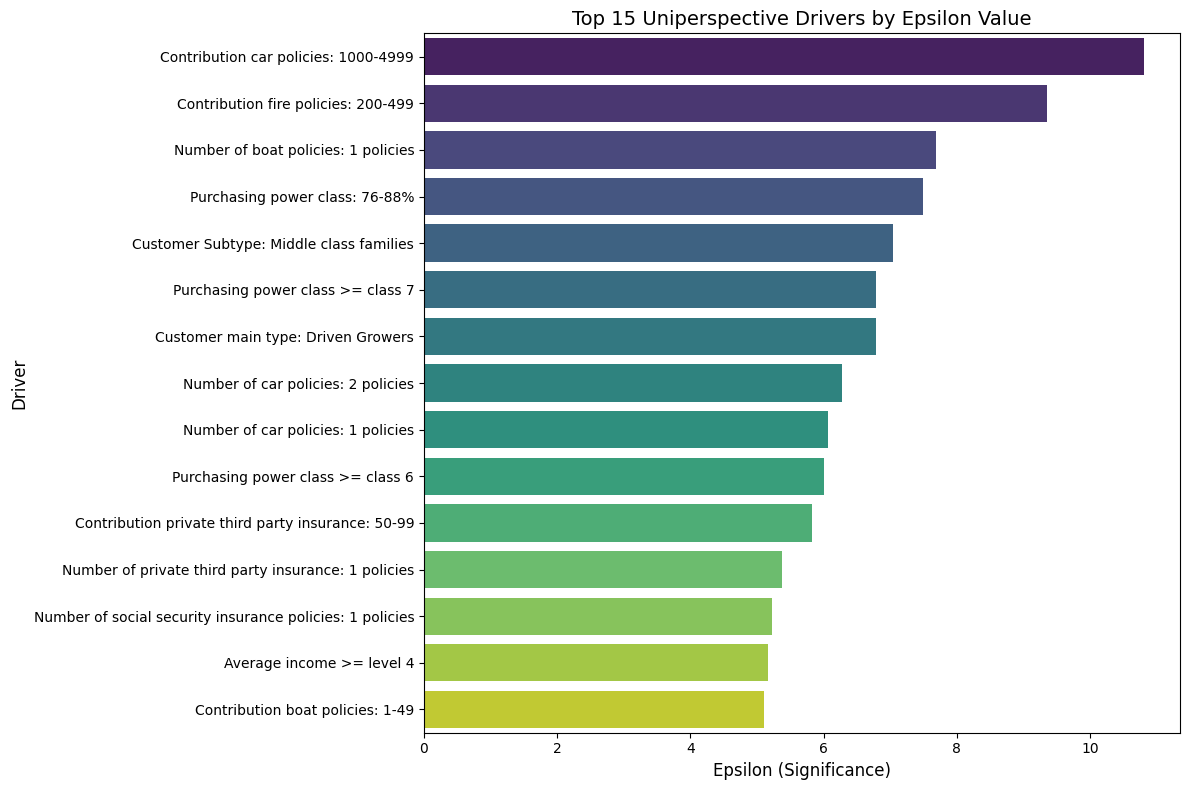

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot top uniperspective drivers
plt.figure(figsize=(12, 8))
sns.barplot(x='Epsilon', y='Driver', data=output_df.head(15), palette='viridis', hue='Driver', legend=False)
plt.title('Top 15 Uniperspective Drivers by Epsilon Value', fontsize=14)
plt.xlabel('Epsilon (Significance)', fontsize=12)
plt.ylabel('Driver', fontsize=12)
plt.tight_layout()
plt.show()

Lift charts (lift = how mich better is the model compared to a random selection), depending on the number of customers selected.

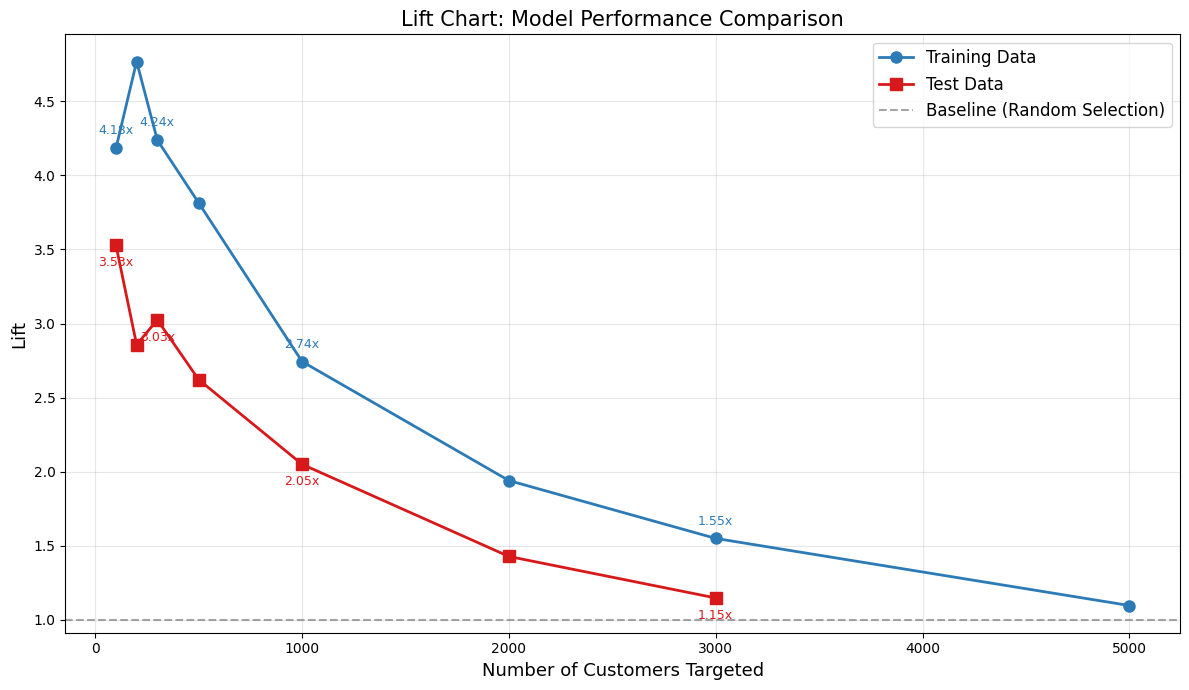

In [74]:
# Create data for lift chart - both training and test
lifts_train = []
lifts_test = []
percentiles = [100, 200, 300, 500, 1000, 2000, 3000, 5000]

# Calculate baseline rates
baseline_train = df['CARAVAN'].mean()
baseline_test = test_df['CARAVAN'].mean()

# Calculate lifts for training data
for n in percentiles:
    if n <= len(customer_scores):
        lift = customer_scores.head(n)['Actual'].mean() / baseline_train
        lifts_train.append(lift)

# Calculate lifts for test data
for n in percentiles:
    if n <= len(test_scores):
        lift = test_scores.head(n)['Actual'].mean() / baseline_test
        lifts_test.append(lift)

# Plot lift chart with both datasets
plt.figure(figsize=(12, 7))

# Training data line
plt.plot(percentiles[:len(lifts_train)], lifts_train, 'o-', 
         linewidth=2, markersize=8, color='#2C7BB6', label='Training Data')

# Test data line
plt.plot(percentiles[:len(lifts_test)], lifts_test, 's-', 
         linewidth=2, markersize=8, color='#D7191C', label='Test Data')

plt.axhline(y=1, color='gray', linestyle='--', alpha=0.7, label='Baseline (Random Selection)')

# Enhance the chart
plt.title('Lift Chart: Model Performance Comparison', fontsize=15)
plt.xlabel('Number of Customers Targeted', fontsize=13)
plt.ylabel('Lift', fontsize=13)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# Add value annotations at key points
for i, (x, y) in enumerate(zip(percentiles[:len(lifts_train)], lifts_train)):
    if i % 2 == 0:  # Annotate every other point to avoid clutter
        plt.annotate(f'{y:.2f}x', (x, y), textcoords="offset points", 
                    xytext=(0,10), ha='center', fontsize=9, color='#2C7BB6')

for i, (x, y) in enumerate(zip(percentiles[:len(lifts_test)], lifts_test)):
    if i % 2 == 0:  # Annotate every other point
        plt.annotate(f'{y:.2f}x', (x, y), textcoords="offset points", 
                    xytext=(0,-15), ha='center', fontsize=9, color='#D7191C')

plt.tight_layout()
plt.show()

Comparison of how well the model performs (Precision@k) for training and test data.

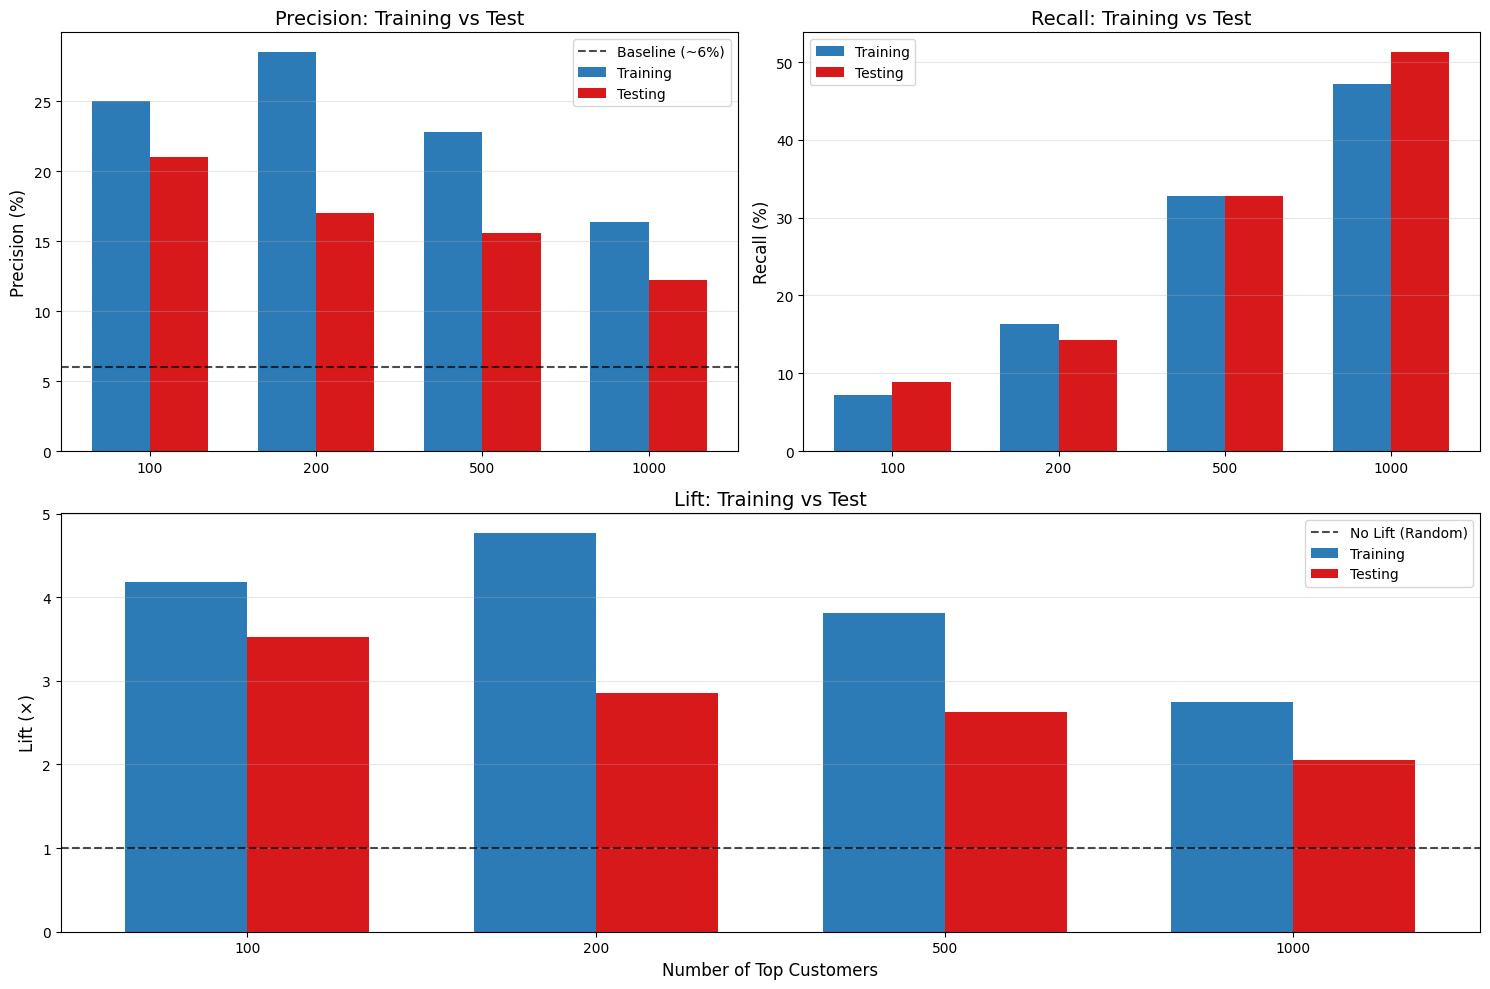

LaTeX Table for Publication:

\begin{table}[htbp]
\centering
\caption{Model Performance Metrics: Training vs Test Data}
\begin{tabular}{r|cc|cc|cc}
\toprule
\multirow{2}{*}{Top N} & \multicolumn{2}{c|}{Precision (\%)} & \multicolumn{2}{c|}{Recall (\%)} & \multicolumn{2}{c}{Lift (×)} \\
 & Training & Testing & Training & Testing & Training & Testing \\
\midrule
100 & 25.0 & 21.0 & 7.2 & 8.8 & 4.18 & 3.53 \\
200 & 28.5 & 17.0 & 16.4 & 14.3 & 4.77 & 2.86 \\
500 & 22.8 & 15.6 & 32.8 & 32.8 & 3.81 & 2.62 \\
1000 & 16.4 & 12.2 & 47.1 & 51.3 & 2.74 & 2.05 \\
\bottomrule
\end{tabular}
\label{tab:model-performance}
\end{table}



In [83]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.gridspec import GridSpec

# Expanded metrics data
thresholds = [100, 200, 500, 1000]

metrics_data = {
    'Precision (Training)': [train_precision[k] for k in thresholds],
    'Precision (Testing)': [test_precision[k] for k in thresholds],
    'Recall (Training)': [train_recall[k] for k in thresholds],
    'Recall (Testing)': [test_recall[k] for k in thresholds],
    'Lift (Training)': [train_lift[k] for k in thresholds],
    'Lift (Testing)': [test_lift[k] for k in thresholds]
}

# Create a DataFrame for easy plotting and table generation
df_metrics = pd.DataFrame(metrics_data, index=thresholds)
df_metrics.index.name = 'Top N Customers'

# Create a figure with 3 subplots
fig = plt.figure(figsize=(15, 10))
gs = GridSpec(2, 2, figure=fig)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

# Plot precision
train_color = '#2C7BB6'
test_color = '#D7191C'
baseline_color = 'black'
width = 0.35

# 1. Precision subplot
x = range(len(thresholds))
ax1.bar([i - width/2 for i in x], df_metrics['Precision (Training)'], width, label='Training', color=train_color)
ax1.bar([i + width/2 for i in x], df_metrics['Precision (Testing)'], width, label='Testing', color=test_color)
ax1.axhline(y=6.0, color=baseline_color, linestyle='--', alpha=0.7, label='Baseline (~6%)')
ax1.set_title('Precision: Training vs Test', fontsize=14)
ax1.set_ylabel('Precision (%)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(thresholds)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# 2. Recall subplot
ax2.bar([i - width/2 for i in x], df_metrics['Recall (Training)'], width, label='Training', color=train_color)
ax2.bar([i + width/2 for i in x], df_metrics['Recall (Testing)'], width, label='Testing', color=test_color)
ax2.set_title('Recall: Training vs Test', fontsize=14)
ax2.set_ylabel('Recall (%)', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(thresholds)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. Lift subplot
ax3.bar([i - width/2 for i in x], df_metrics['Lift (Training)'], width, label='Training', color=train_color)
ax3.bar([i + width/2 for i in x], df_metrics['Lift (Testing)'], width, label='Testing', color=test_color)
ax3.axhline(y=1.0, color=baseline_color, linestyle='--', alpha=0.7, label='No Lift (Random)')
ax3.set_title('Lift: Training vs Test', fontsize=14)
ax3.set_ylabel('Lift (×)', fontsize=12)
ax3.set_xlabel('Number of Top Customers', fontsize=12)
ax3.set_xticks(x)
ax3.set_xticklabels(thresholds)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Generate LaTeX table
latex_table = """
\\begin{table}[htbp]
\\centering
\\caption{Model Performance Metrics: Training vs Test Data}
\\begin{tabular}{r|cc|cc|cc}
\\toprule
\\multirow{2}{*}{Top N} & \\multicolumn{2}{c|}{Precision (\\%)} & \\multicolumn{2}{c|}{Recall (\\%)} & \\multicolumn{2}{c}{Lift (×)} \\\\
 & Training & Testing & Training & Testing & Training & Testing \\\\
\\midrule
"""

for idx, row in df_metrics.iterrows():
    latex_table += f"{idx} & {row['Precision (Training)']:.1f} & {row['Precision (Testing)']:.1f} & "
    latex_table += f"{row['Recall (Training)']:.1f} & {row['Recall (Testing)']:.1f} & "
    latex_table += f"{row['Lift (Training)']:.2f} & {row['Lift (Testing)']:.2f} \\\\\n"

latex_table += """\\bottomrule
\\end{tabular}
\\label{tab:model-performance}
\\end{table}
"""

print("LaTeX Table for Publication:")
print(latex_table)

The cumulative gains chart displays the percentage of total mobile home insurance purchasers that can be identified when targeting different percentages of customers based on model scores, demonstrating how much more efficiently the model performs compared to random selection.

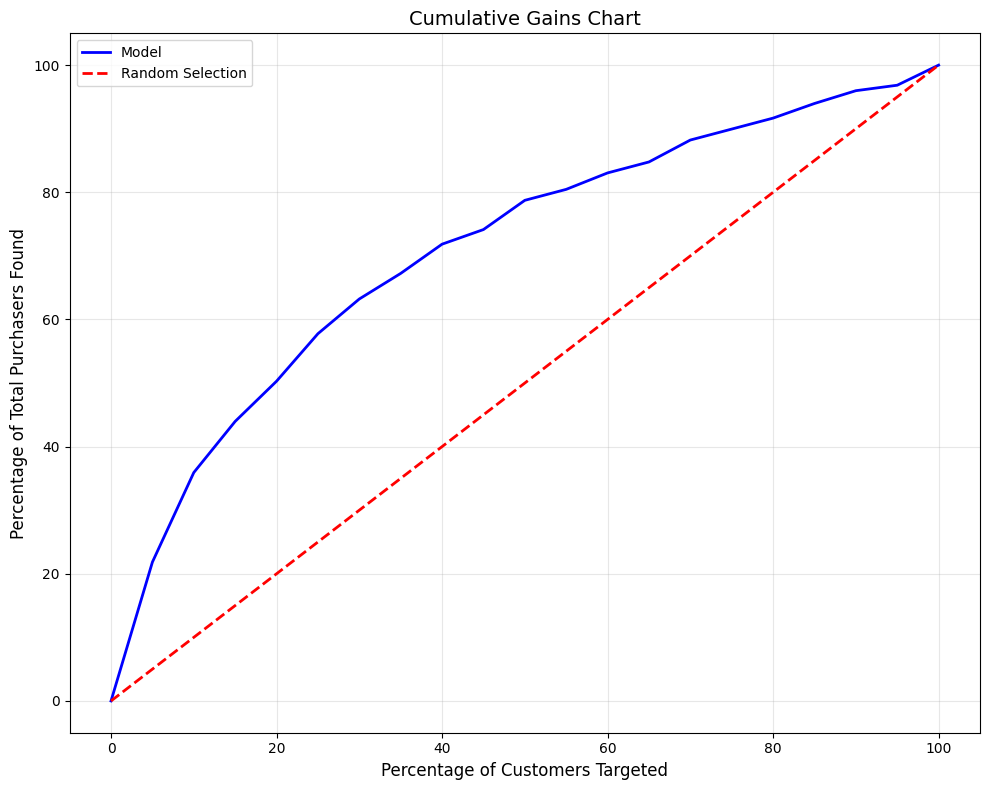

In [77]:
# Calculate cumulative response
def calculate_cumulative_response(scores_df, total_population):
    cumulative = []
    purchasers_found = 0
    step_size = 100
    
    for i in range(step_size, len(scores_df) + 1, step_size):
        purchasers_found += scores_df.iloc[i-step_size:i]['Actual'].sum()
        cumulative.append(purchasers_found / total_population * 100)
    
    return cumulative

population_pcts = [i for i in range(0, 101, 5)]
random_selection = population_pcts.copy()  # Diagonal line

# Calculate actual cumulative responses (percentage of total purchasers found)
steps = [int(len(customer_scores) * p/100) for p in population_pcts]
cumulative_pct = [customer_scores.head(n)['Actual'].sum() / total_positive * 100 
                  if n > 0 else 0 for n in steps]

# Plot
plt.figure(figsize=(10, 8))
plt.plot(population_pcts, cumulative_pct, 'b-', linewidth=2, label='Model')
plt.plot(population_pcts, random_selection, 'r--', linewidth=2, label='Random Selection')
plt.title('Cumulative Gains Chart', fontsize=14)
plt.xlabel('Percentage of Customers Targeted', fontsize=12)
plt.ylabel('Percentage of Total Purchasers Found', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

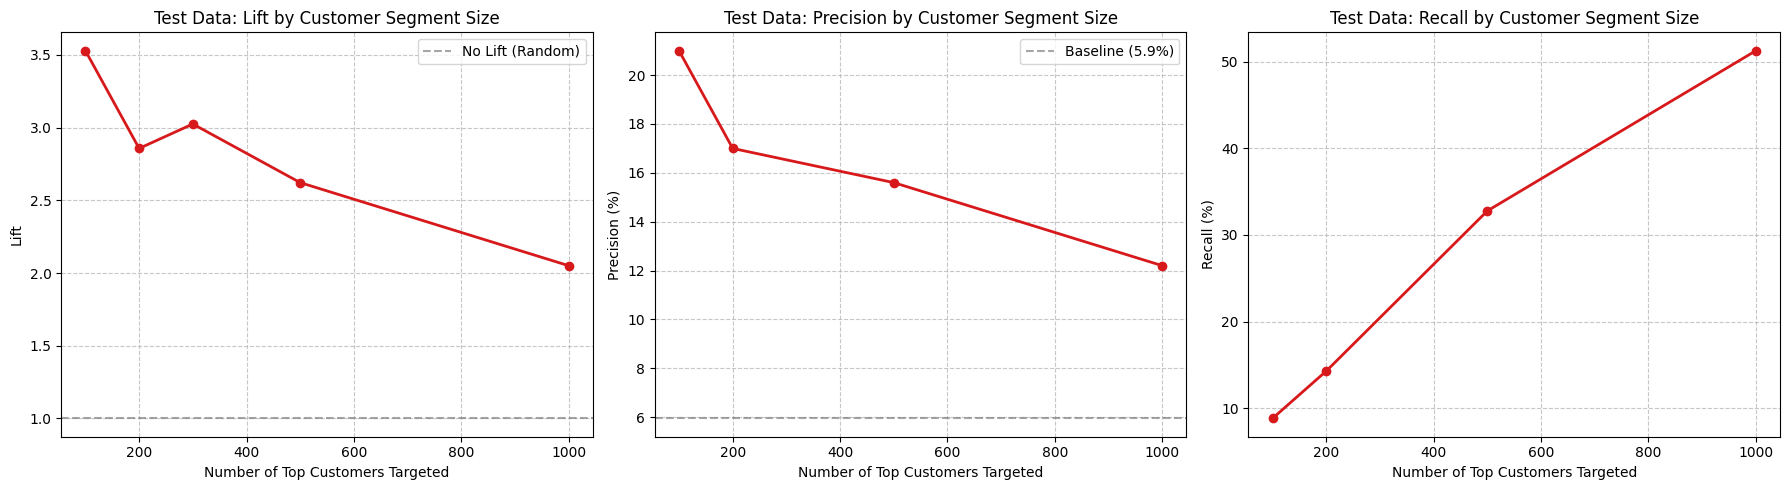

In [88]:
# Extract and visualize the lift pattern
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data from the current model
lift_segments = sorted(test_lift.keys())
lift_values = [test_lift[k] for k in lift_segments]

# For precision and recall - use common keys between dictionaries
precision_segments = sorted([k for k in test_precision.keys()])
precision_values = [test_precision[k] for k in precision_segments]

recall_segments = sorted([k for k in test_recall.keys()])
recall_values = [test_recall[k] for k in recall_segments]


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot lift values
axes[0].plot(lift_segments, lift_values, marker='o', linestyle='-', linewidth=2, color='#D7191C')
axes[0].set_xlabel('Number of Top Customers Targeted')
axes[0].set_ylabel('Lift')
axes[0].set_title('Test Data: Lift by Customer Segment Size')
axes[0].axhline(y=1.0, color='gray', linestyle='--', alpha=0.7, label='No Lift (Random)')
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend()

# Plot precision values
axes[1].plot(precision_segments, precision_values, marker='o', linestyle='-', linewidth=2, color='#D7191C')
axes[1].set_xlabel('Number of Top Customers Targeted')
axes[1].set_ylabel('Precision (%)')
axes[1].set_title('Test Data: Precision by Customer Segment Size')
axes[1].axhline(y=test_baseline, color='gray', linestyle='--', alpha=0.7, 
                label=f'Baseline ({test_baseline:.1f}%)')
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend()

# Plot recall values
axes[2].plot(recall_segments, recall_values, marker='o', linestyle='-', linewidth=2, color='#D7191C')
axes[2].set_xlabel('Number of Top Customers Targeted')
axes[2].set_ylabel('Recall (%)')
axes[2].set_title('Test Data: Recall by Customer Segment Size')
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

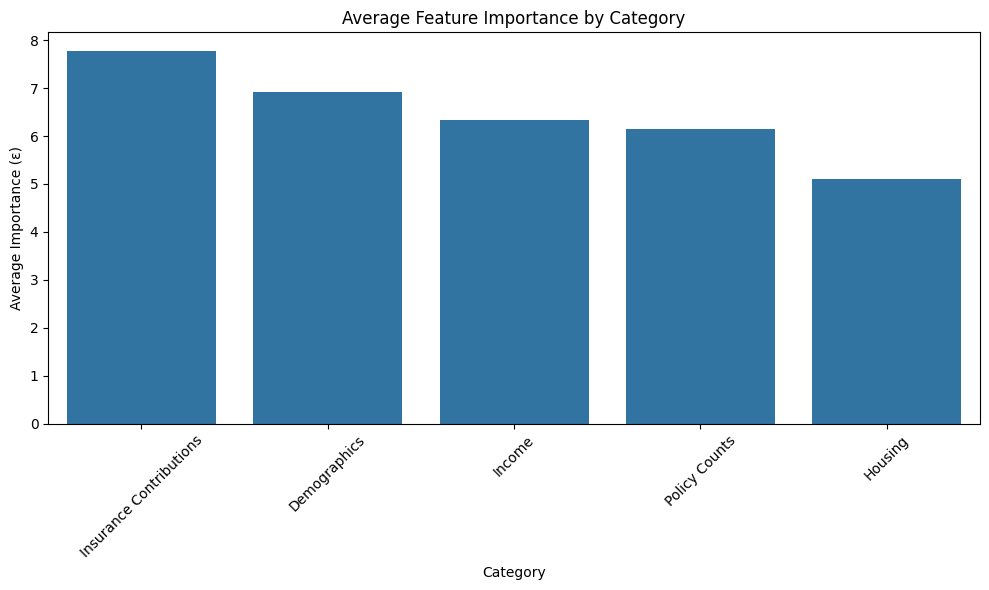

                  Category  Average Importance (ε)
4  Insurance Contributions                   7.775
0             Demographics                   6.910
2                   Income                   6.325
3            Policy Counts                   6.140
1                  Housing                   5.100


In [79]:
# Analyze importance of different feature categories
import pandas as pd

# Extract the features used in the model and their categories
feature_categories = {
    'Demographics': ['MOSTYPE', 'MOSHOOFD'],
    'Housing': ['MHHUUR', 'MHKOOP'],
    'Income': ['MINKGEM', 'MKOOPKLA'],
    'Policy Counts': ['APERSAUT', 'APLEZIER', 'AWAPART', 'ABYSTAND'],
    'Insurance Contributions': ['PBRAND', 'PPERSAUT', 'PPLEZIER', 'PWAPART']
}

# Calculate average epsilon values per category
category_importance = {}
for category, features in feature_categories.items():
    category_epsilons = []
    for feature in features:
        # Find all epsilon values for this feature in top_drivers
        feature_epsilons = [row['Epsilon'] for _, row in top_drivers.iterrows() 
                           if row['Descripción'].startswith(feature)]
        if feature_epsilons:
            # Take the maximum epsilon value for this feature
            category_epsilons.append(max(feature_epsilons))
    
    if category_epsilons:
        category_importance[category] = sum(category_epsilons) / len(category_epsilons)

# Convert to DataFrame for visualization
category_df = pd.DataFrame({
    'Category': list(category_importance.keys()),
    'Average Importance (ε)': list(category_importance.values())
}).sort_values('Average Importance (ε)', ascending=False)

# Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(data=category_df, x='Category', y='Average Importance (ε)')
plt.title('Average Feature Importance by Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(category_df)

Starting 5-fold cross-validation...

Processing fold 1/5
Fold 1 completed in 0.6 seconds
Fold 1 metrics: Lift@100 = 2.73x, Precision@100 = 19.00%

Processing fold 2/5
Fold 2 completed in 0.5 seconds
Fold 2 metrics: Lift@100 = 4.15x, Precision@100 = 26.00%

Processing fold 3/5
Fold 3 completed in 0.5 seconds
Fold 3 metrics: Lift@100 = 2.82x, Precision@100 = 15.00%

Processing fold 4/5
Fold 4 completed in 0.5 seconds
Fold 4 metrics: Lift@100 = 2.78x, Precision@100 = 16.00%

Processing fold 5/5
Fold 5 completed in 0.6 seconds
Fold 5 metrics: Lift@100 = 3.94x, Precision@100 = 22.00%

Cross-validation completed in 2.8 seconds

Cross-Validation Results:
   Fold  Features Used  Baseline Rate  Precision@100  Recall@100  Lift@100  \
0     1             15       6.952790           19.0   23.456790  2.732716   
1     2             15       6.266094           26.0   35.616438  4.149315   
2     3             16       5.326460           15.0   24.193548  2.816129   
3     4             15       5.7

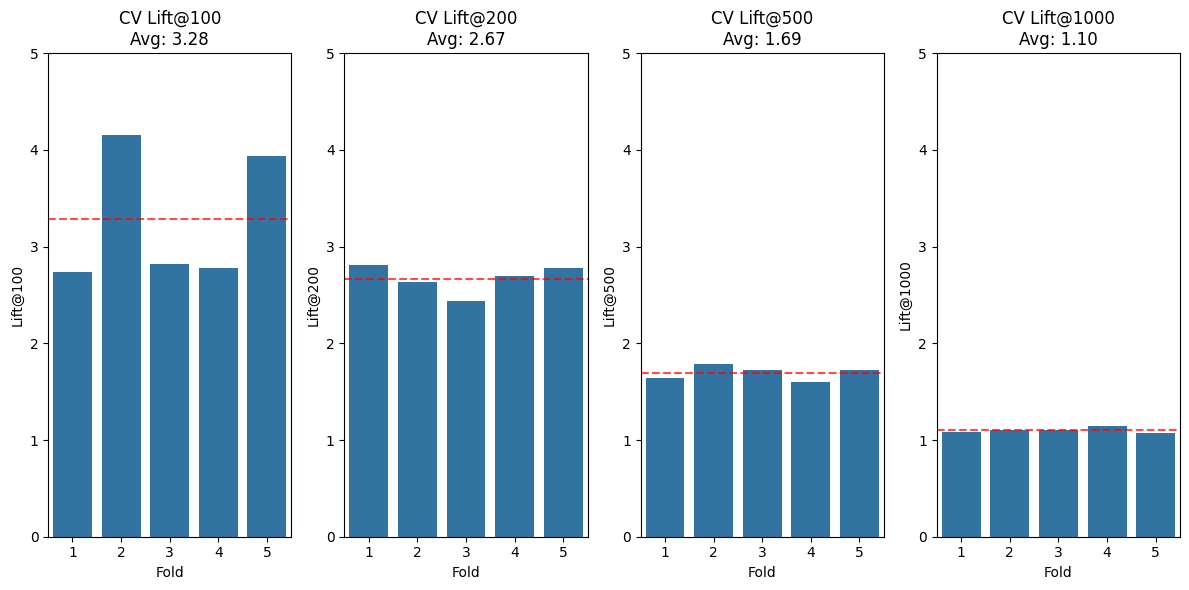

In [80]:
# Implement k-fold cross-validation using existing functions
from sklearn.model_selection import KFold
import numpy as np
import pandas as pd
import time

def run_cross_validation(df, n_splits=5, random_state=42):
    """
    Perform k-fold cross-validation using the existing Naive Bayes implementation
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    cv_results = []
    fold_start_time = time.time()
    
    print(f"Starting {n_splits}-fold cross-validation...")
    
    for fold, (train_idx, test_idx) in enumerate(kf.split(df)):
        print(f"\nProcessing fold {fold+1}/{n_splits}")
        fold_start = time.time()
        
        # Split data into training and test sets for this fold
        train_df = df.iloc[train_idx].reset_index(drop=True)
        test_df = df.iloc[test_idx].reset_index(drop=True)
        
        # Step 1: Calculate uniperspective drivers on training data
        fold_results = []
        for feature in features_to_analyze:
            # Determine category (reusing existing code)
            if feature.startswith('M'):
                if feature in ['MOSTYPE', 'MOSHOOFD', 'MGEMLEEF', 'MAANTHUI', 'MGEMOMV']:
                    category = 'Demographics'
                elif feature in ['MGODRK', 'MGODPR', 'MGODOV', 'MGODGE']:
                    category = 'Religion'
                elif feature in ['MRELGE', 'MRELSA', 'MRELOV', 'MFALLEEN', 'MFGEKIND', 'MFWEKIND']:
                    category = 'Family Status'
                elif feature in ['MOPLHOOG', 'MOPLMIDD', 'MOPLLAAG']:
                    category = 'Education'
                elif feature in ['MBERHOOG', 'MBERZELF', 'MBERBOER', 'MBERMIDD', 'MBERARBG', 'MBERARBO']:
                    category = 'Professional Status'
                elif feature in ['MSKA', 'MSKB1', 'MSKB2', 'MSKC', 'MSKD']:
                    category = 'Social Class'
                elif feature in ['MHHUUR', 'MHKOOP']:
                    category = 'Housing'
                elif feature in ['MAUT1', 'MAUT2', 'MAUT0']:
                    category = 'Transportation'
                elif feature in ['MZFONDS', 'MZPART']:
                    category = 'Health Insurance'
                elif feature in ['MINKM30', 'MINK3045', 'MINK4575', 'MINK7512', 'MINK123M', 'MINKGEM', 'MKOOPKLA']:
                    category = 'Income'
                else:
                    category = 'Sociodemographic'
            elif feature.startswith('P'):
                category = 'Insurance Contributions'
            elif feature.startswith('A'):
                category = 'Policy Counts'
            else:
                category = 'Other'
            
            # Analyze unique values - but on the training data
            unique_values = sorted(train_df[feature].unique())
            for value in unique_values:
                description = f"{feature} = {value}"
                
                # Use the same function but with training data
                stats = {
                    'Subcategoría': category,
                    'Descripción': description
                }
                
                # Calculate statistics manually since we need to modify the function to use train_df
                if is_threshold := False:
                    condition = train_df[feature] >= value
                else:
                    condition = train_df[feature] == value
                
                # Count instances
                N_X = condition.sum()
                N_CX = ((train_df['CARAVAN'] == 1) & condition).sum()
                N_not_CX = N_X - N_CX
                
                # Calculate probabilities
                P_C_given_X = N_CX / N_X if N_X > 0 else 0
                prior_probability = train_df['CARAVAN'].mean()
                
                # Calculate Epsilon
                if N_X > 0 and prior_probability < 1 and prior_probability > 0:
                    epsilon = (N_X * (P_C_given_X - prior_probability)) / (N_X * prior_probability * (1 - prior_probability))**0.5
                else:
                    epsilon = 0
                
                stats.update({
                    'N(X)': N_X,
                    'N(CX)': N_CX,
                    'Epsilon': round(epsilon, 2),
                    'Feature': feature,
                    'Value': value,
                    'Is_Threshold': is_threshold
                })
                
                fold_results.append(stats)
            
            # For income and purchasing power features, also analyze threshold values
            if feature in ['MINKGEM', 'MKOOPKLA']:
                for threshold in range(1, 10):
                    description = f"{feature} >= {threshold}"
                    
                    # Calculate statistics manually
                    condition = train_df[feature] >= threshold
                    
                    # Count instances
                    N_X = condition.sum()
                    N_CX = ((train_df['CARAVAN'] == 1) & condition).sum()
                    N_not_CX = N_X - N_CX
                    
                    # Calculate probabilities
                    P_C_given_X = N_CX / N_X if N_X > 0 else 0
                    prior_probability = train_df['CARAVAN'].mean()
                    
                    # Calculate Epsilon
                    if N_X > 0 and prior_probability < 1 and prior_probability > 0:
                        epsilon = (N_X * (P_C_given_X - prior_probability)) / (N_X * prior_probability * (1 - prior_probability))**0.5
                    else:
                        epsilon = 0
                    
                    stats = {
                        'Subcategoría': 'Income',
                        'Descripción': description,
                        'N(X)': N_X,
                        'N(CX)': N_CX,
                        'Epsilon': round(epsilon, 2),
                        'Feature': feature,
                        'Value': threshold,
                        'Is_Threshold': True
                    }
                    
                    fold_results.append(stats)
        
        # Create DataFrame with results and sort by epsilon
        fold_results_df = pd.DataFrame(fold_results)
        fold_results_df = fold_results_df.sort_values(by='Epsilon', ascending=False)
        
        # Step 2: Calculate multiperspective drivers using the top uniperspective drivers
        top_n = 40  # Adjust based on computational capacity
        top_uniperspective = fold_results_df.head(top_n)
        
        multiperspective_results = []
        
        # Generate and evaluate pairs
        for i, row1 in top_uniperspective.iterrows():
            feature1 = row1['Feature']
            value1 = row1['Value']
            is_threshold1 = row1['Is_Threshold']
            
            for j, row2 in top_uniperspective.iterrows():
                if i >= j:  # Avoid duplicates and same-feature pairs
                    continue
                    
                feature2 = row2['Feature']
                value2 = row2['Value']
                is_threshold2 = row2['Is_Threshold']
                
                # Avoid pairs of the same feature
                if feature1 == feature2:
                    continue
                
                # Create conditions for both features
                if is_threshold1:
                    condition1 = train_df[feature1] >= value1
                else:
                    condition1 = train_df[feature1] == value1
                    
                if is_threshold2:
                    condition2 = train_df[feature2] >= value2
                else:
                    condition2 = train_df[feature2] == value2
                
                # Combined condition (logical AND)
                combined_condition = condition1 & condition2
                
                # Count instances
                N_X = combined_condition.sum()
                N_CX = ((train_df['CARAVAN'] == 1) & combined_condition).sum()
                N_not_CX = N_X - N_CX
                
                # Calculate probabilities
                P_C_given_X = N_CX / N_X if N_X > 0 else 0
                prior_probability = train_df['CARAVAN'].mean()
                
                # Calculate Epsilon
                if N_X > 0 and prior_probability < 1 and prior_probability > 0:
                    epsilon = (N_X * (P_C_given_X - prior_probability)) / (N_X * prior_probability * (1 - prior_probability))**0.5
                else:
                    epsilon = 0
                
                # Only consider pairs with sufficient support (at least 30 customers)
                if N_X >= 30:
                    multiperspective_results.append({
                        'Feature1': feature1,
                        'Value1': value1,
                        'Is_Threshold1': is_threshold1,
                        'Feature2': feature2,
                        'Value2': value2,
                        'Is_Threshold2': is_threshold2,
                        'N(X)': N_X,
                        'N(CX)': N_CX,
                        'Epsilon': round(epsilon, 2)
                    })
        
        # Convert to DataFrame and sort by epsilon
        multiperspective_df = pd.DataFrame(multiperspective_results)
        if not multiperspective_df.empty:
            multiperspective_df = multiperspective_df.sort_values(by='Epsilon', ascending=False)
        
        # Step 3: Score test data using these drivers
        top_uniperspective_for_scoring = fold_results_df.head(20)
        top_multiperspective_for_scoring = multiperspective_df.head(10) if not multiperspective_df.empty else pd.DataFrame()
        
        # Use the evaluate_on_test_data function, but modify it to use our test_df
        # Get prior probability from training data
        prior_probability = train_df['CARAVAN'].mean()
        prior_odds = prior_probability / (1 - prior_probability)
        log_prior = math.log(prior_odds) if prior_odds > 0 else 0
        
        # Initialize array for scores
        test_scores = np.ones(len(test_df)) * log_prior
        
        # Track features used to avoid duplicate counting
        used_features = set()
        
        # First use the top multiperspective pairs
        if not multiperspective_df.empty:
            for _, pair in top_multiperspective_for_scoring.iterrows():
                feature1 = pair['Feature1']
                value1 = pair['Value1']
                is_threshold1 = pair['Is_Threshold1']
                
                feature2 = pair['Feature2']
                value2 = pair['Value2']
                is_threshold2 = pair['Is_Threshold2']
                
                # Skip if either feature already used
                if feature1 in used_features or feature2 in used_features:
                    continue
                    
                # Add both features to the used set
                used_features.add(feature1)
                used_features.add(feature2)
                
                # Calculate likelihood ratios for this pair
                if is_threshold1:
                    condition1 = test_df[feature1] >= value1
                else:
                    condition1 = test_df[feature1] == value1
                    
                if is_threshold2:
                    condition2 = test_df[feature2] >= value2
                else:
                    condition2 = test_df[feature2] == value2
                    
                condition = condition1 & condition2
                
                # Use statistics from training data
                positive_instances = train_df['CARAVAN'].sum()
                negative_instances = len(train_df) - positive_instances
                
                # Count from training data
                train_condition1 = train_df[feature1] >= value1 if is_threshold1 else train_df[feature1] == value1
                train_condition2 = train_df[feature2] >= value2 if is_threshold2 else train_df[feature2] == value2
                train_condition = train_condition1 & train_condition2
                
                # Calculate conditional probabilities with Laplace smoothing
                count_with_C = ((train_df['CARAVAN'] == 1) & train_condition).sum() + 1
                count_with_not_C = (train_condition & (train_df['CARAVAN'] == 0)).sum() + 1
                
                P_X_given_C = count_with_C / (positive_instances + 2)
                P_X_given_not_C = count_with_not_C / (negative_instances + 2)
                
                # Calculate log likelihood ratio for this pair
                log_ratio = math.log(P_X_given_C / P_X_given_not_C)
                
                # Apply to matching test customers
                test_scores[condition] += log_ratio
                
                # For test customers that don't match this pair, apply the complement likelihood
                comp_count_with_C = positive_instances - ((train_df['CARAVAN'] == 1) & train_condition).sum() + 1
                comp_count_with_not_C = negative_instances - (train_condition & (train_df['CARAVAN'] == 0)).sum() + 1
                comp_P_X_given_C = comp_count_with_C / (positive_instances + 2)
                comp_P_X_given_not_C = comp_count_with_not_C / (negative_instances + 2)
                comp_log_ratio = math.log(comp_P_X_given_C / comp_P_X_given_not_C)
                
                test_scores[~condition] += comp_log_ratio
        
        # Then add top uniperspective drivers for features not yet used
        for _, row in top_uniperspective_for_scoring.iterrows():
            feature = row['Feature']
            value = row['Value']
            is_threshold = row['Is_Threshold']
            
            # Skip if feature already used in pairs
            if feature in used_features:
                continue
                
            # Add feature to used set
            used_features.add(feature)
            
            # Create condition for test data
            if is_threshold:
                condition = test_df[feature] >= value
            else:
                condition = test_df[feature] == value
                
            # Create condition for training data (to get statistics)
            if is_threshold:
                train_condition = train_df[feature] >= value
            else:
                train_condition = train_df[feature] == value
            
            # Count from training data
            positive_instances = train_df['CARAVAN'].sum()
            negative_instances = len(train_df) - positive_instances
            
            # Calculate conditional probabilities with Laplace smoothing
            count_with_C = ((train_df['CARAVAN'] == 1) & train_condition).sum() + 1
            count_with_not_C = (train_condition & (train_df['CARAVAN'] == 0)).sum() + 1
            
            P_X_given_C = count_with_C / (positive_instances + 2)
            P_X_given_not_C = count_with_not_C / (negative_instances + 2)
            
            # Calculate log likelihood ratio
            log_ratio = math.log(P_X_given_C / P_X_given_not_C)
            
            # Apply to matching test customers
            test_scores[condition] += log_ratio
            
            # For test customers that don't match, apply the complement likelihood
            comp_count_with_C = positive_instances - ((train_df['CARAVAN'] == 1) & train_condition).sum() + 1
            comp_count_with_not_C = negative_instances - (train_condition & (train_df['CARAVAN'] == 0)).sum() + 1
            comp_P_X_given_C = comp_count_with_C / (positive_instances + 2)
            comp_P_X_given_not_C = comp_count_with_not_C / (negative_instances + 2)
            comp_log_ratio = math.log(comp_P_X_given_C / comp_P_X_given_not_C)
            
            test_scores[~condition] += comp_log_ratio
            
        # Create DataFrame with customer IDs and scores
        fold_scores_df = pd.DataFrame({
            'CustomerID': test_df['NID'],
            'Score': test_scores,
            'Probability': 1 / (1 + np.exp(-test_scores)),  # Convert log-odds to probability
            'Actual': test_df['CARAVAN']
        })
        
        # Sort by score in descending order
        fold_scores_df = fold_scores_df.sort_values(by='Score', ascending=False)
        
        # Calculate metrics for this fold
        total_positive_test = test_df['CARAVAN'].sum()
        test_baseline = total_positive_test / len(test_df)
        
        metrics = {}
        for k in [100, 200, 500, 1000]:
            if len(fold_scores_df) >= k:
                top_k = fold_scores_df.head(k)
                precision = top_k['Actual'].sum() / k
                recall = top_k['Actual'].sum() / total_positive_test
                lift = precision / test_baseline if test_baseline > 0 else 0
                
                metrics[f'Precision@{k}'] = precision * 100
                metrics[f'Recall@{k}'] = recall * 100
                metrics[f'Lift@{k}'] = lift
        
        # Add results for this fold
        fold_results = {
            'Fold': fold + 1,
            'Features Used': len(used_features),
            'Baseline Rate': test_baseline * 100,
            **metrics
        }
        
        cv_results.append(fold_results)
        
        fold_time = time.time() - fold_start
        print(f"Fold {fold+1} completed in {fold_time:.1f} seconds")
        print(f"Fold {fold+1} metrics: Lift@100 = {metrics.get('Lift@100', 'N/A'):.2f}x, " +
              f"Precision@100 = {metrics.get('Precision@100', 'N/A'):.2f}%")
    
    # Create DataFrame with all CV results
    cv_df = pd.DataFrame(cv_results)
    
    # Calculate average metrics
    avg_metrics = {col: cv_df[col].mean() for col in cv_df.columns if col not in ['Fold', 'Features Used']}
    std_metrics = {col: cv_df[col].std() for col in cv_df.columns if col not in ['Fold', 'Features Used']}
    
    total_time = time.time() - fold_start_time
    print(f"\nCross-validation completed in {total_time:.1f} seconds")
    print("\nCross-Validation Results:")
    print(cv_df)
    
    print("\nAverage Metrics:")
    for metric, value in avg_metrics.items():
        print(f"{metric}: {value:.2f} (±{std_metrics[metric]:.2f})")
    
    return cv_df, avg_metrics, std_metrics

# Run cross-validation
cv_results, avg_metrics, std_metrics = run_cross_validation(df, n_splits=5)

# Visualize cross-validation results
plt.figure(figsize=(12, 6))
metrics_to_plot = ['Lift@100', 'Lift@200', 'Lift@500', 'Lift@1000']

for i, metric in enumerate(metrics_to_plot):
    plt.subplot(1, len(metrics_to_plot), i+1)
    sns.barplot(x='Fold', y=metric, data=cv_results)
    plt.axhline(y=avg_metrics[metric], color='r', linestyle='--', alpha=0.7)
    plt.title(f'CV {metric}\nAvg: {avg_metrics[metric]:.2f}')
    plt.ylim(bottom=0, top=5)

plt.tight_layout()
plt.show()

Revenue Impact Analysis:
   Segment Size Targeted Conversion  Targeted Policies Targeted Revenue  \
0            10               40.0%                  4        €1,000.00   
1            50               28.0%                 14        €3,500.00   
2           100               21.0%                 21        €5,250.00   
3           200               17.0%                 34        €8,500.00   
4           500               15.6%                 78       €19,500.00   
5          1000               12.2%                122       €30,500.00   
6          2000                8.5%                170       €42,500.00   
7          3000                6.8%                205       €51,250.00   
8          4000                5.9%                238       €59,500.00   

  Targeted Profit Targeted ROI  Untargeted Policies Untargeted Profit  \
0         €900.00         9.00                    0           €-50.00   
1       €3,000.00         6.00                    2           €250.00   
2    

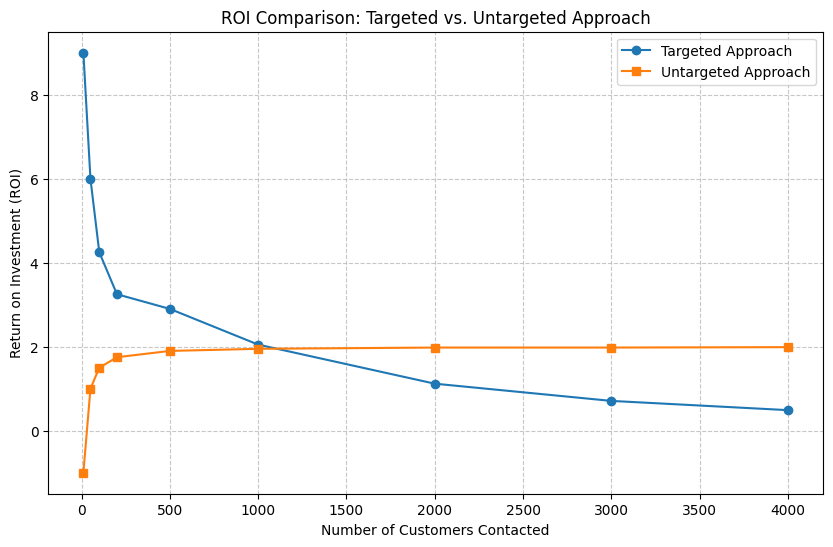

In [81]:
# Analyze potential revenue impact of targeted vs. untargeted approaches
import numpy as np

# Assumptions
avg_policy_value = 250  # Average annual premium in EUR
cost_per_call_untargeted = 5  # Cost of sales call in EUR
cost_per_call_targeted = 10  # Cost of targeted sales call in EUR
conversion_rate_untargeted = conversion_rate_untargeted = df['CARAVAN'].mean()

segment_sizes = [10, 50, 100, 200, 500, 1000, 2000, 3000, 4000]
conversion_rates_targeted = {}

for k in segment_sizes:
    if len(test_scores) >= k:
        # Calculate precision (which is the conversion rate for that segment)
        precision = test_scores.head(k)['Actual'].sum() / k
        conversion_rates_targeted[k] = precision

# Calculate economics
results = []
for segment_size, conv_rate in conversion_rates_targeted.items():
    # Targeted approach
    calls_made = segment_size
    policies_sold = int(segment_size * conv_rate)
    revenue = policies_sold * avg_policy_value
    cost = calls_made * cost_per_call_targeted
    profit = revenue - cost
    roi = profit / cost if cost > 0 else 0
    
    # Untargeted approach (same number of calls)
    untargeted_policies = int(segment_size * conversion_rate_untargeted)
    untargeted_revenue = untargeted_policies * avg_policy_value
    untargeted_cost = segment_size * cost_per_call_untargeted
    untargeted_profit = untargeted_revenue - untargeted_cost
    untargeted_roi = untargeted_profit / untargeted_cost if untargeted_cost > 0 else 0
    
    # Improvement
    profit_improvement = profit - untargeted_profit
    roi_improvement = roi - untargeted_roi
    
    results.append({
        'Segment Size': segment_size,
        'Targeted Conversion': f"{conv_rate:.1%}",
        'Targeted Policies': policies_sold,
        'Targeted Revenue': f"€{revenue:,.2f}",
        'Targeted Profit': f"€{profit:,.2f}",
        'Targeted ROI': f"{roi:.2f}",
        'Untargeted Policies': untargeted_policies,
        'Untargeted Profit': f"€{untargeted_profit:,.2f}",
        'Untargeted ROI': f"{untargeted_roi:.2f}",
        'Profit Improvement': f"€{profit_improvement:,.2f}",
        'ROI Improvement': f"{roi_improvement:.2f}"
    })

# Display results
revenue_df = pd.DataFrame(results)
print("Revenue Impact Analysis:")
print(revenue_df)

# Plot ROI comparison
plt.figure(figsize=(10, 6))
segment_sizes = list(conversion_rates_targeted.keys())
targeted_roi = [float(row['Targeted ROI'].replace('€', '')) for row in results]
untargeted_roi = [float(row['Untargeted ROI'].replace('€', '')) for row in results]

plt.plot(segment_sizes, targeted_roi, marker='o', label='Targeted Approach')
plt.plot(segment_sizes, untargeted_roi, marker='s', label='Untargeted Approach')
plt.xlabel('Number of Customers Contacted')
plt.ylabel('Return on Investment (ROI)')
plt.title('ROI Comparison: Targeted vs. Untargeted Approach')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Bayesian Necessity and Sufficiency Analysis:
                                         Feature                  Value  \
0                      Contribution car policies              1000-4999   
1                     Contribution fire policies                200-499   
2                        Number of boat policies             1 policies   
3                         Purchasing power class                 76-88%   
4                               Customer Subtype  Middle class families   
5                         Purchasing power class                   >= 7   
6                             Customer main type         Driven Growers   
7                         Number of car policies             2 policies   
8                         Number of car policies             1 policies   
9                         Purchasing power class                   >= 6   
10    Contribution private third party insurance                  50-99   
11       Number of private third party insurance       

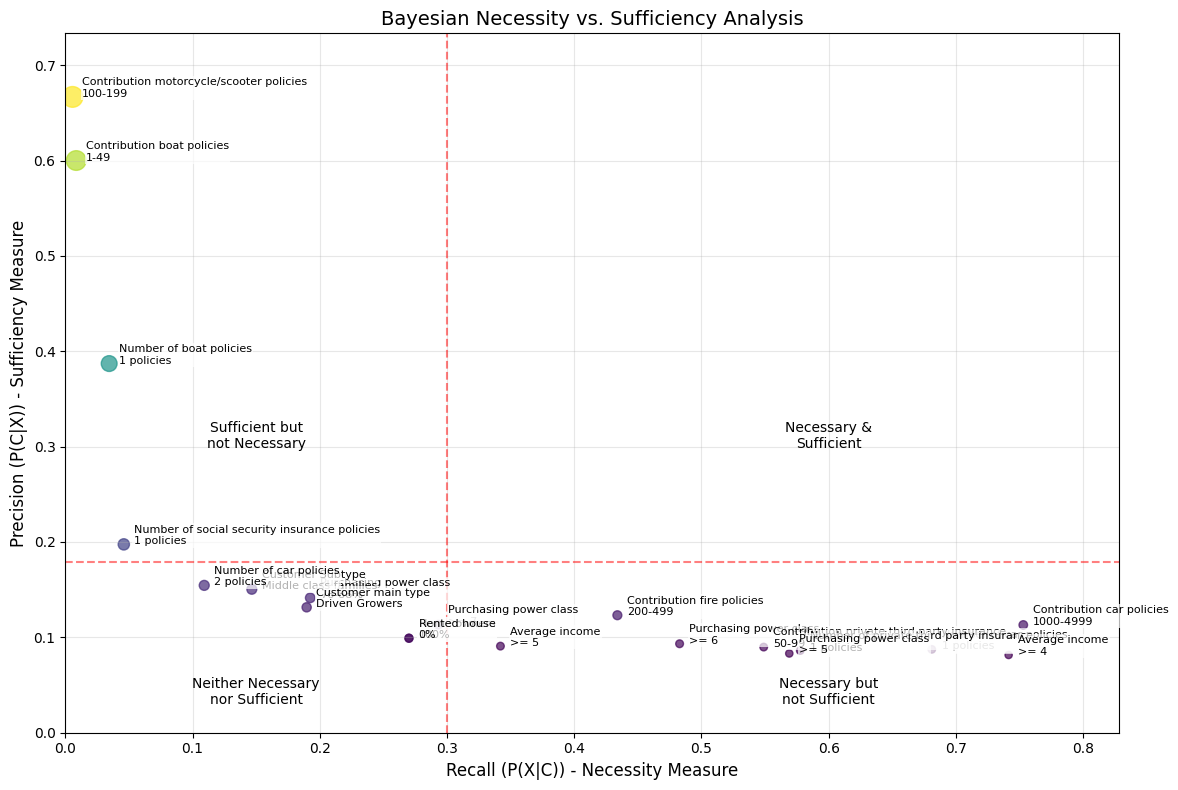

In [82]:
# Improved necessary and sufficient conditions analysis
feature_analysis = []

# Extract top features from uniperspective analysis
key_features = []
for _, row in top_drivers.head(20).iterrows(): # results_df.iterrows():
    desc = row['Descripción']
    
    if '>=' in desc:
        parts = desc.split(' >= ')
        feature = parts[0]
        value = int(parts[1])
        is_threshold = True
    else:
        parts = desc.split(' = ')
        feature = parts[0]
        value = int(parts[1])
        is_threshold = False
    
    key_features.append((feature, value, is_threshold))

total_customers = len(df)
total_purchasers = df['CARAVAN'].sum()
base_rate = total_purchasers / total_customers

for feature, value, is_threshold in key_features:
    # Get feature description
    if feature in field_descriptions:
        feature_desc = field_descriptions[feature]
    else:
        feature_desc = feature
    
    # Get value description
    if is_threshold:
        value_label = f">= {value}"
    elif feature.startswith('A'):
        value_label = f"{value} policies"
    elif feature.startswith('P') and value in contribution_descriptions:
        value_label = contribution_descriptions[value]
    elif feature == 'MOSTYPE' and value in customer_subtypes:
        value_label = customer_subtypes[value]
    elif feature == 'MGEMLEEF' and value in age_descriptions:
        value_label = age_descriptions[value]
    elif feature == 'MOSHOOFD' and value in customer_main_descriptions:
        value_label = customer_main_descriptions[value]
    elif feature.startswith('M') and value in percentage_descriptions:
        value_label = percentage_descriptions[value]
    else:
        value_label = str(value)
    
    # Calculate probabilities
    if is_threshold:
        condition = (df[feature] >= value)
    else:
        condition = (df[feature] == value)
        
    customers_with_feature = condition.sum()
    p_x = customers_with_feature / total_customers
    
    purchasers_with_feature = (condition & (df['CARAVAN'] == 1)).sum()
    p_x_given_c = purchasers_with_feature / total_purchasers if total_purchasers > 0 else 0
    p_c_given_x = purchasers_with_feature / customers_with_feature if customers_with_feature > 0 else 0
    
    # Calculate metrics
    lift = p_c_given_x / base_rate if base_rate > 0 else 0
    
    # Calculate coverage and precision
    coverage = p_x  # How common is this feature overall?
    precision = p_c_given_x  # How likely are people with this feature to purchase?
    recall = p_x_given_c  # What percentage of purchasers have this feature?
    
    # Determine necessity and sufficiency based on more appropriate metrics
    necessary = recall > 0.3  # Feature appears in >30% of all positive cases
    sufficient = precision > (3 * base_rate)  # Feature triples the purchase probability
    
    # Store the analysis
    feature_analysis.append({
        'Feature': f"{feature_desc}",
        'Value': value_label,
        'Coverage': f"{p_x:.2%}",  # How common is the feature
        'Precision': f"{p_c_given_x:.2%}",  # Lift numerator
        'Recall': f"{p_x_given_c:.2%}",  # Necessity measure
        'Lift': f"{lift:.2f}x",  # Single correct ratio
        'Necessary': "Yes" if necessary else "No",
        'Sufficient': "Yes" if sufficient else "No",
        'Interpretation': ("Necessary & Sufficient" if (necessary and sufficient) else 
                        ("Necessary but not Sufficient" if necessary else 
                         ("Sufficient but not Necessary" if sufficient else 
                          "Neither Necessary nor Sufficient")))
    })

# Display the analysis with the additional ratio columns
necessity_df = pd.DataFrame(feature_analysis)
print("Bayesian Necessity and Sufficiency Analysis:")
print(necessity_df)

# Create visualization of necessity vs sufficiency using the ratios
plt.figure(figsize=(12, 8))

# Use recall and precision for the axes
recall_values = [float(r.strip('%'))/100 for r in necessity_df['Recall']]
precision_values = [float(p.strip('%'))/100 for p in necessity_df['Precision']]
lift_values = [float(l.replace('x', '')) for l in necessity_df['Lift']]

# Create scatter plot with sized markers based on lift
plt.scatter(recall_values, precision_values, s=[l*20 for l in lift_values], 
           alpha=0.7, c=lift_values, cmap='viridis')

# Add feature labels
for i, row in necessity_df.iterrows():
    recall_val = float(row['Recall'].strip('%'))/100
    precision_val = float(row['Precision'].strip('%'))/100
    
    # Only annotate if it has sufficient lift or is particularly necessary/sufficient
    lift_val = float(row['Lift'].replace('x', ''))
    if lift_val > 2.0 or recall_val > 0.2 or precision_val > (2*base_rate):
        plt.annotate(
            f"{row['Feature']}\n{row['Value']}", 
            (recall_val, precision_val),
            xytext=(7, 0), textcoords='offset points',
            fontsize=8, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
        )

# Add quadrant lines with corrected thresholds
plt.axhline(y=3*base_rate, color='r', linestyle='--', alpha=0.5)
plt.axvline(x=0.3, color='r', linestyle='--', alpha=0.5)

# Update quadrant labels
plt.text(0.15, base_rate*5, "Sufficient but\nnot Necessary", ha='center')
plt.text(0.6, base_rate*5, "Necessary &\nSufficient", ha='center')
plt.text(0.15, base_rate*0.5, "Neither Necessary\nnor Sufficient", ha='center')
plt.text(0.6, base_rate*0.5, "Necessary but\nnot Sufficient", ha='center')

# Set labels and title
plt.xlabel('Recall (P(X|C)) - Necessity Measure', fontsize=12)
plt.ylabel('Precision (P(C|X)) - Sufficiency Measure', fontsize=12)
plt.title('Bayesian Necessity vs. Sufficiency Analysis', fontsize=14)

max_recall = max(recall_values) * 1.1
max_precision = max(precision_values) * 1.1
plt.xlim(0, max(0.5, max_recall))
plt.ylim(0, max(base_rate*8, max_precision))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()